In [1]:
import os
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
# =========================
# CONFIG
# =========================

BASE_DIR = Path("/data/shared/fsibilla/clean_code/Q1/bayesian")

# Put here the experiments you want to compare
EXPERIMENTS = [
    "eth_micron",
    "lka_micron",
    "lka_vam",
    "moz_vam",
    "nga_micron",
    "nga_mics",
    "yem_mvam",
    "zwe_mics"
]

RESULT_FILENAME = "eval_adm1.csv"

# Optional: restrict to a subset of variables
VARIABLES_TO_KEEP = None
# example:
# VARIABLES_TO_KEEP = ["wscore", "space_per_person", "avg_adult_education"]

In [3]:
def norm_place(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.replace("’","'").replace("‘","'").replace("`","'")
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    s = s.replace("'", "")
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\bgovernorate\b", "", s).strip()
    return s


def safe_mean(x):
    x = pd.Series(x).astype(float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return float(x.mean())


def safe_sd(x, ddof=0):
    x = pd.Series(x).astype(float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return float(x.std(ddof=ddof))


def standardized_abs_error(true_value, pred_value, sd_ref):
    """
    |pred - true| / sd_ref
    """
    if not np.isfinite(true_value) or not np.isfinite(pred_value) or not np.isfinite(sd_ref) or sd_ref == 0:
        return np.nan
    return float(abs(pred_value - true_value) / sd_ref)

In [4]:
all_tables = []

for exp_name in EXPERIMENTS:
    fp = BASE_DIR / exp_name / RESULT_FILENAME
    
    if not fp.exists():
        print(f"[WARNING] Missing file for experiment '{exp_name}': {fp}")
        continue

    df = pd.read_csv(fp)
    df["experiment"] = exp_name
    
    # normalize ADM1 name just in case
    if "adm1" in df.columns:
        df["adm1_norm"] = df["adm1"].map(norm_place)
    else:
        raise ValueError(f"'adm1' column not found in {fp}")

    all_tables.append(df)

if not all_tables:
    raise ValueError("No result tables were loaded. Check BASE_DIR and EXPERIMENTS.")

results_all = pd.concat(all_tables, ignore_index=True)

if VARIABLES_TO_KEEP is not None:
    results_all = results_all[results_all["variable"].isin(VARIABLES_TO_KEEP)].copy()

print(f"Loaded rows: {len(results_all):,}")
print(f"Experiments loaded: {results_all['experiment'].nunique()}")
print(f"Variables: {results_all['variable'].nunique()}")
print(f"ADM1 units: {results_all['adm1_norm'].nunique()}")

results_all.head()

Loaded rows: 715
Experiments loaded: 8
Variables: 23
ADM1 units: 100


,adm1,variable,true_mean,gen_mean,gen_std,gen_mean_between_seed_sd,n_seeds,bayes_mean,bayes_std,bayes_mean_between_seed_sd,n_seeds_bayes,gen_abs_err,bayes_abs_err,gen_sq_err,bayes_sq_err,delta_abs_err,winner_abs,experiment,adm1_norm
0,Addis Ababa,avg_adult_education,12.336833,12.760252,0.861341,1.677205,5,12.150581,1.109721,2.469583,5,0.423418,0.186253,0.179283,0.034690,0.237166,Bayesian MVN,eth_micron,addis ababa
1,Addis Ababa,fe_ai,29.319499,29.450531,4.908192,10.622815,5,37.237903,7.103853,15.868578,5,0.131032,7.918404,0.017169,62.701122,-7.787372,RealNVP,eth_micron,addis ababa
2,Addis Ababa,fol_ai,290.654229,320.704579,51.852998,113.127171,5,318.957264,88.208892,196.948114,5,30.050350,28.303034,903.023522,801.061745,1.747316,Bayesian MVN,eth_micron,addis ababa
3,Addis Ababa,log_exp,7.018489,7.154453,0.208630,0.428185,5,7.051668,0.532352,1.189605,5,0.135964,0.033178,0.018486,0.001101,0.102786,Bayesian MVN,eth_micron,addis ababa
4,Addis Ababa,va_ai,398.217953,382.082750,84.462057,183.887539,5,408.262777,85.450582,190.409135,5,16.135203,10.044824,260.344777,100.898490,6.090379,Bayesian MVN,eth_micron,addis ababa


In [5]:
# SD of true ADM1 means, by experiment and variable
true_sd_by_exp_var = (
    results_all
    .groupby(["experiment", "variable"], as_index=False)["true_mean"]
    .std(ddof=0)
    .rename(columns={"true_mean": "sd_true_across_adm1"})
)

results_eval = results_all.merge(
    true_sd_by_exp_var,
    on=["experiment", "variable"],
    how="left"
)

results_eval["gen_abs_err_std"] = results_eval.apply(
    lambda r: standardized_abs_error(r["true_mean"], r["gen_mean"], r["sd_true_across_adm1"]),
    axis=1
)

results_eval["bayes_abs_err_std"] = results_eval.apply(
    lambda r: standardized_abs_error(r["true_mean"], r["bayes_mean"], r["sd_true_across_adm1"]),
    axis=1
)

results_eval["delta_abs_err_std"] = (
    results_eval["gen_abs_err_std"] - results_eval["bayes_abs_err_std"]
)

results_eval["winner_abs_std"] = np.where(
    results_eval["bayes_abs_err_std"] < results_eval["gen_abs_err_std"],
    "Bayesian MVN",
    np.where(
        results_eval["bayes_abs_err_std"] > results_eval["gen_abs_err_std"],
        "Generated",
        "Tie"
    )
)

results_eval.head()

,adm1,variable,true_mean,gen_mean,gen_std,gen_mean_between_seed_sd,n_seeds,bayes_mean,bayes_std,bayes_mean_between_seed_sd,...,bayes_sq_err,delta_abs_err,winner_abs,experiment,adm1_norm,sd_true_across_adm1,gen_abs_err_std,bayes_abs_err_std,delta_abs_err_std,winner_abs_std
0,Addis Ababa,avg_adult_education,12.336833,12.760252,0.861341,1.677205,5,12.150581,1.109721,2.469583,...,0.034690,0.237166,Bayesian MVN,eth_micron,addis ababa,2.722030,0.155552,0.068424,0.087128,Bayesian MVN
1,Addis Ababa,fe_ai,29.319499,29.450531,4.908192,10.622815,5,37.237903,7.103853,15.868578,...,62.701122,-7.787372,RealNVP,eth_micron,addis ababa,8.514303,0.015390,0.930012,-0.914622,Generated
2,Addis Ababa,fol_ai,290.654229,320.704579,51.852998,113.127171,5,318.957264,88.208892,196.948114,...,801.061745,1.747316,Bayesian MVN,eth_micron,addis ababa,91.135927,0.329731,0.310558,0.019173,Bayesian MVN
3,Addis Ababa,log_exp,7.018489,7.154453,0.208630,0.428185,5,7.051668,0.532352,1.189605,...,0.001101,0.102786,Bayesian MVN,eth_micron,addis ababa,0.656021,0.207255,0.050575,0.156680,Bayesian MVN
4,Addis Ababa,va_ai,398.217953,382.082750,84.462057,183.887539,5,408.262777,85.450582,190.409135,...,100.898490,6.090379,Bayesian MVN,eth_micron,addis ababa,146.891775,0.109844,0.068382,0.041462,Bayesian MVN


In [6]:
overall_eval = pd.DataFrame({
    "n_rows": [len(results_eval)],
    "n_experiments": [results_eval["experiment"].nunique()],
    "n_variables": [results_eval["variable"].nunique()],
    "n_adm1": [results_eval["adm1_norm"].nunique()],
    
    "gen_abs_err_raw_mean": [safe_mean(results_eval["gen_abs_err"]) if "gen_abs_err" in results_eval.columns else np.nan],
    "bayes_abs_err_raw_mean": [safe_mean(results_eval["bayes_abs_err"]) if "bayes_abs_err" in results_eval.columns else np.nan],
    
    "gen_abs_err_std_mean": [safe_mean(results_eval["gen_abs_err_std"])],
    "bayes_abs_err_std_mean": [safe_mean(results_eval["bayes_abs_err_std"])],
    
    "gen_abs_err_std_median": [results_eval["gen_abs_err_std"].median()],
    "bayes_abs_err_std_median": [results_eval["bayes_abs_err_std"].median()],
    
    "mean_delta_abs_err_std_gen_minus_bayes": [safe_mean(results_eval["delta_abs_err_std"])],
    
    "bayes_win_rate": [(results_eval["winner_abs_std"] == "Bayesian MVN").mean()],
    "generated_win_rate": [(results_eval["winner_abs_std"] == "Generated").mean()],
    "tie_rate": [(results_eval["winner_abs_std"] == "Tie").mean()],
})

overall_eval.T

,0
n_rows,715.000000
n_experiments,8.000000
n_variables,23.000000
n_adm1,100.000000
gen_abs_err_raw_mean,8.008982
bayes_abs_err_raw_mean,8.754629
gen_abs_err_std_mean,0.616106
bayes_abs_err_std_mean,0.708716
gen_abs_err_std_median,0.468109
bayes_abs_err_std_median,0.522574


In [7]:
by_variable_eval = (
    results_eval
    .groupby("variable", as_index=False)
    .agg(
        n_obs=("variable", "size"),
        sd_true_across_adm1=("sd_true_across_adm1", "mean"),
        
        gen_abs_err_std_mean=("gen_abs_err_std", "mean"),
        bayes_abs_err_std_mean=("bayes_abs_err_std", "mean"),
        
        gen_abs_err_std_median=("gen_abs_err_std", "median"),
        bayes_abs_err_std_median=("bayes_abs_err_std", "median"),
        
        delta_abs_err_std_mean=("delta_abs_err_std", "mean"),
        bayes_win_rate=("winner_abs_std", lambda x: (x == "Bayesian MVN").mean()),
        generated_win_rate=("winner_abs_std", lambda x: (x == "Generated").mean()),
        tie_rate=("winner_abs_std", lambda x: (x == "Tie").mean()),
    )
    .sort_values("delta_abs_err_std_mean")
    .reset_index(drop=True)
)

by_variable_eval

,variable,n_obs,sd_true_across_adm1,gen_abs_err_std_mean,bayes_abs_err_std_mean,gen_abs_err_std_median,bayes_abs_err_std_median,delta_abs_err_std_mean,bayes_win_rate,generated_win_rate,tie_rate
0,zn_mg,9,0.500377,0.677630,1.866170,0.627773,1.222951,-1.188540,0.111111,0.888889,0.0
1,fe_mg,9,1.403883,0.506200,1.014289,0.258284,1.109036,-0.508089,0.333333,0.666667,0.0
2,vita_rae_mcg,9,26.819249,1.000233,1.481850,0.653546,1.418983,-0.481617,0.444444,0.555556,0.0
3,FGProtein,11,0.882505,0.917491,1.076553,0.851896,1.453262,-0.159062,0.454545,0.545455,0.0
4,FGHIron,11,0.440326,0.667278,0.817174,0.653381,0.542801,-0.149895,0.454545,0.545455,0.0
5,vitb12_mcg,9,0.316810,0.655693,0.777135,0.755535,0.628663,-0.121443,0.333333,0.666667,0.0
6,FES,9,0.022552,0.904001,1.016380,1.035706,0.563639,-0.112379,0.444444,0.555556,0.0
7,log_exp,57,0.455219,0.576052,0.688161,0.417674,0.393570,-0.112109,0.473684,0.526316,0.0
8,fe_ai,48,4.099423,0.685821,0.787301,0.570778,0.666005,-0.101480,0.333333,0.666667,0.0
9,rCSI,42,2.075864,0.683156,0.779971,0.491017,0.501720,-0.096815,0.404762,0.595238,0.0


In [8]:
scatter_df = (
    results_eval
    .groupby(["experiment", "variable"], as_index=False)
    .agg(
        bayes_err_mean=("bayes_abs_err_std", "mean"),
        bayes_err_sd=("bayes_abs_err_std", "std"),
        gen_err_mean=("gen_abs_err_std", "mean"),
        gen_err_sd=("gen_abs_err_std", "std"),
        n=("adm1_norm", "size"),
    )
)

scatter_df["label"] = scatter_df["experiment"].astype(str) + " | " + scatter_df["variable"].astype(str)

scatter_df.head()

,experiment,variable,bayes_err_mean,bayes_err_sd,gen_err_mean,gen_err_sd,n,label
0,eth_micron,avg_adult_education,0.329804,0.305609,0.539526,0.430796,11,eth_micron | avg_adult_education
1,eth_micron,fe_ai,0.846693,0.471925,0.652508,0.631060,11,eth_micron | fe_ai
2,eth_micron,fol_ai,0.673792,0.436884,0.537900,0.436119,11,eth_micron | fol_ai
3,eth_micron,log_exp,0.186946,0.209773,0.512098,0.471713,11,eth_micron | log_exp
4,eth_micron,va_ai,0.708462,0.832695,0.564123,0.620264,11,eth_micron | va_ai


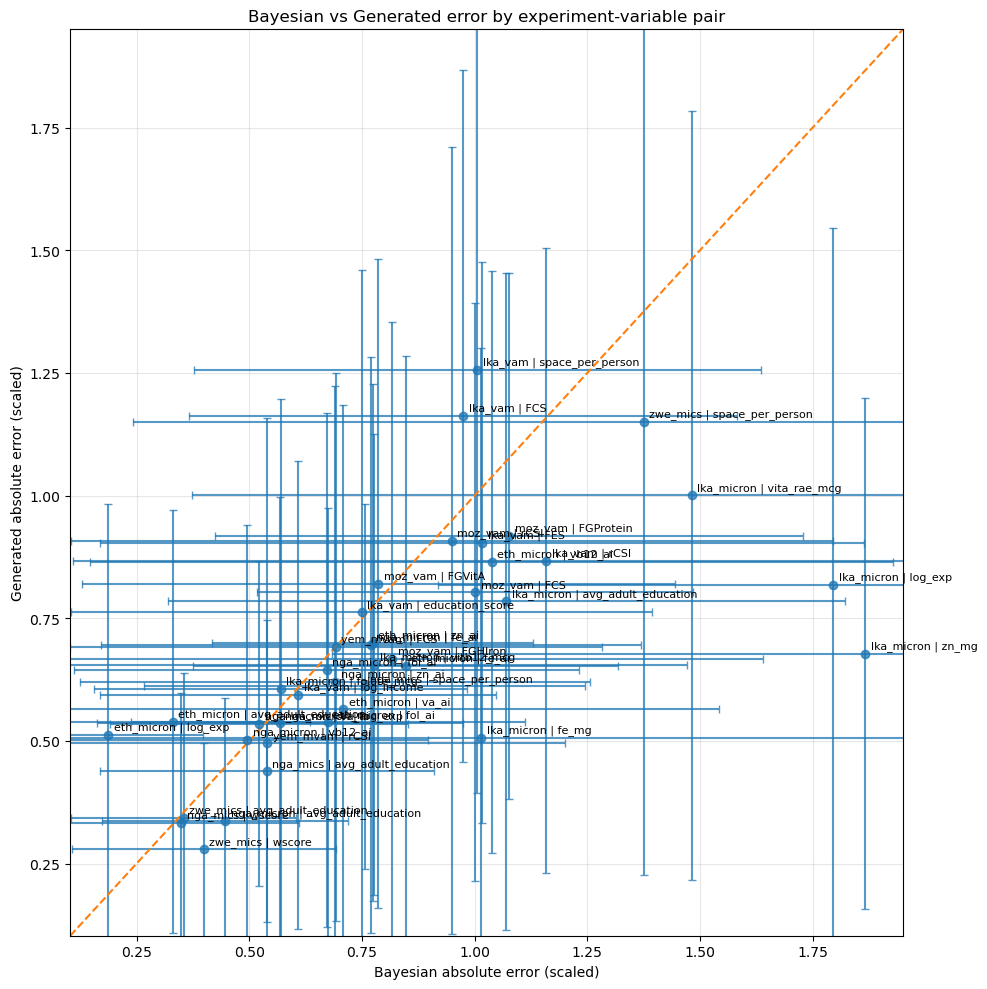

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = scatter_df.dropna(subset=["bayes_err_mean", "gen_err_mean"]).copy()

fig, ax = plt.subplots(figsize=(10, 10))

ax.errorbar(
    plot_df["bayes_err_mean"],
    plot_df["gen_err_mean"],
    xerr=plot_df["bayes_err_sd"],
    yerr=plot_df["gen_err_sd"],
    fmt="o",
    capsize=3,
    alpha=0.75
)

for _, r in plot_df.iterrows():
    ax.annotate(
        r["label"],
        (r["bayes_err_mean"], r["gen_err_mean"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

all_vals = np.concatenate([
    plot_df["bayes_err_mean"].values,
    plot_df["gen_err_mean"].values
])

vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)
pad = 0.05 * (vmax - vmin) if vmax > vmin else 0.1

line_min = max(0, vmin - pad)
line_max = vmax + pad

ax.plot([line_min, line_max], [line_min, line_max], linestyle="--")

ax.set_xlim(line_min, line_max)
ax.set_ylim(line_min, line_max)

ax.set_xlabel("Bayesian absolute error (scaled)")
ax.set_ylabel("Generated absolute error (scaled)")
ax.set_title("Bayesian vs Generated error by experiment-variable pair")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
df = pd.read_csv('/data/shared/fsibilla/clean_code/Q1/bayesian/lka_vam/results/seed_1/rnvp_generated_run0.csv')

In [11]:
max(df['rCSI'])

36.97816610336304

In [12]:
scatter_df.head()

,experiment,variable,bayes_err_mean,bayes_err_sd,gen_err_mean,gen_err_sd,n,label
0,eth_micron,avg_adult_education,0.329804,0.305609,0.539526,0.430796,11,eth_micron | avg_adult_education
1,eth_micron,fe_ai,0.846693,0.471925,0.652508,0.631060,11,eth_micron | fe_ai
2,eth_micron,fol_ai,0.673792,0.436884,0.537900,0.436119,11,eth_micron | fol_ai
3,eth_micron,log_exp,0.186946,0.209773,0.512098,0.471713,11,eth_micron | log_exp
4,eth_micron,va_ai,0.708462,0.832695,0.564123,0.620264,11,eth_micron | va_ai


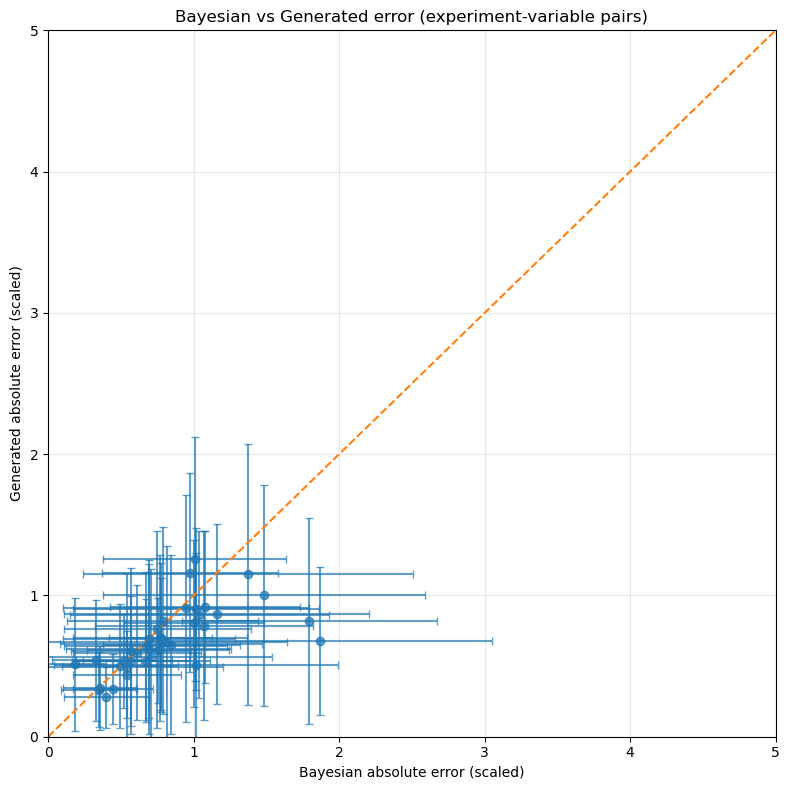

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = scatter_df.dropna(subset=["bayes_err_mean", "gen_err_mean"]).copy()

fig, ax = plt.subplots(figsize=(8, 8))

ax.errorbar(
    plot_df["bayes_err_mean"],
    plot_df["gen_err_mean"],
    xerr=plot_df["bayes_err_sd"],
    yerr=plot_df["gen_err_sd"],
    fmt="o",
    capsize=3,
    alpha=0.7
)

# diagonal y = x
ax.plot([0, 50], [0, 50], linestyle="--")

# fixed limits
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

ax.set_xlabel("Bayesian absolute error (scaled)")
ax.set_ylabel("Generated absolute error (scaled)")
ax.set_title("Bayesian vs Generated error (experiment-variable pairs)")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

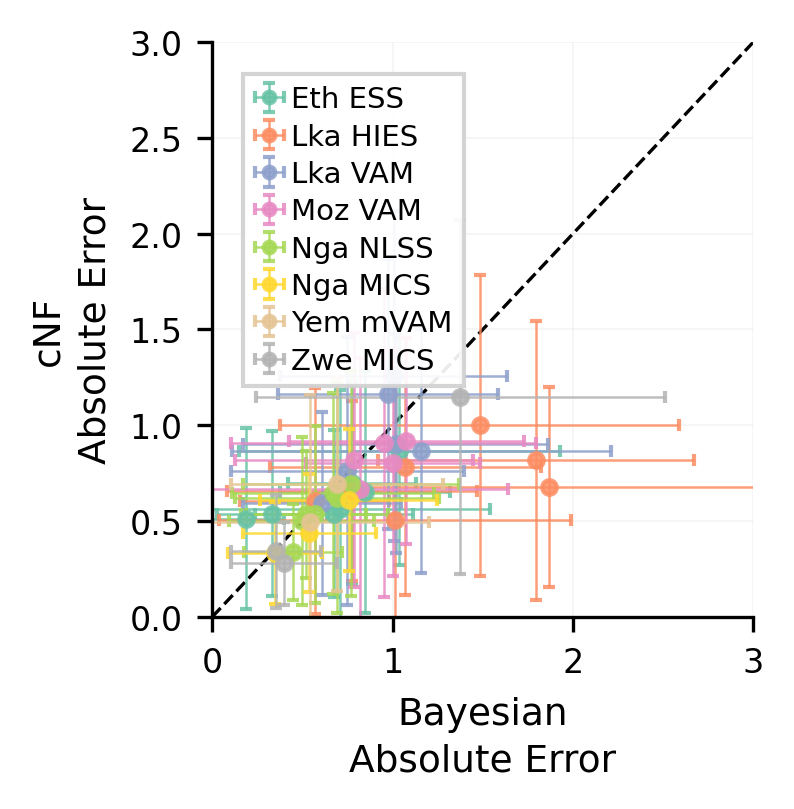

In [14]:
from cycler import cycler
import matplotlib.pyplot as plt
import numpy as np

EXPERIMENT_LABELS = {
    "eth_micron": "Eth ESS",
    "lka_micron": "Lka HIES",
    "lka_vam":    "Lka VAM",
    "moz_vam":    "Moz VAM",
    "nga_micron": "Nga NLSS",
    "nga_mics":   "Nga MICS",
    "yem_mvam":   "Yem mVAM",
    "zwe_mics":   "Zwe MICS",
}

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": cycler("color", plt.get_cmap("Set2").colors),
})

plot_df = scatter_df.dropna(subset=["bayes_err_mean", "gen_err_mean"]).copy()

fig, ax = plt.subplots(figsize=(2.8, 2.8), dpi=300)

lo, hi = 0, 3
ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=0.8, zorder=1)

for exp_id in sorted(plot_df["experiment"].unique()):
    d = plot_df[plot_df["experiment"] == exp_id]
    ax.errorbar(
        d["bayes_err_mean"], d["gen_err_mean"],
        xerr=d["bayes_err_sd"], yerr=d["gen_err_sd"],
        fmt="o", linestyle="none",
        markersize=3.5, alpha=0.85,
        elinewidth=0.6, capsize=1.5,
        zorder=2,
        label=EXPERIMENT_LABELS.get(exp_id, exp_id),
    )

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Bayesian\nAbsolute Error", linespacing=1.4)
ax.set_ylabel("cNF\nAbsolute Error", linespacing=1.4)
ax.grid(True, alpha=0.12, linewidth=0.4)

ax.legend(
    loc="upper left", bbox_to_anchor=(0.03, 0.97),
    ncol=1, frameon=True, framealpha=0.92, edgecolor="0.82", fancybox=False,
    fontsize=7, handlelength=1.0, handletextpad=0.25, labelspacing=0.32,
    borderpad=0.4, markerscale=0.8,
)

fig.tight_layout(pad=1.2)
plt.savefig("/data/shared/fsibilla/clean_code/Q1/bayesian/comp.pdf", bbox_inches="tight")

plt.show()

## is there difference?

In [15]:
import numpy as np
import pandas as pd

ADM1_PLOT_COL = "adm1"   # change to "adm1_norm" if needed

plot_base = results_eval.copy()

# keep only rows where both methods are available
plot_base = plot_base.dropna(subset=["bayes_abs_err_std", "gen_abs_err_std"]).copy()

# unique tuple id
plot_base["tuple_id"] = (
    plot_base["experiment"].astype(str) + " | " +
    plot_base[ADM1_PLOT_COL].astype(str) + " | " +
    plot_base["variable"].astype(str)
)

# long format for violin plot
violins_df = pd.concat([
    plot_base[["tuple_id", "experiment", ADM1_PLOT_COL, "variable", "bayes_abs_err_std"]]
        .rename(columns={"bayes_abs_err_std": "error"})
        .assign(method="Bayesian"),
    plot_base[["tuple_id", "experiment", ADM1_PLOT_COL, "variable", "gen_abs_err_std"]]
        .rename(columns={"gen_abs_err_std": "error"})
        .assign(method="Generated")
], ignore_index=True)

print("Number of paired tuples:", plot_base["tuple_id"].nunique())
violins_df.head()

Number of paired tuples: 693


,tuple_id,experiment,adm1,variable,error,method
0,eth_micron | Addis Ababa | avg_adult_education,eth_micron,Addis Ababa,avg_adult_education,0.068424,Bayesian
1,eth_micron | Addis Ababa | fe_ai,eth_micron,Addis Ababa,fe_ai,0.930012,Bayesian
2,eth_micron | Addis Ababa | fol_ai,eth_micron,Addis Ababa,fol_ai,0.310558,Bayesian
3,eth_micron | Addis Ababa | log_exp,eth_micron,Addis Ababa,log_exp,0.050575,Bayesian
4,eth_micron | Addis Ababa | va_ai,eth_micron,Addis Ababa,va_ai,0.068382,Bayesian


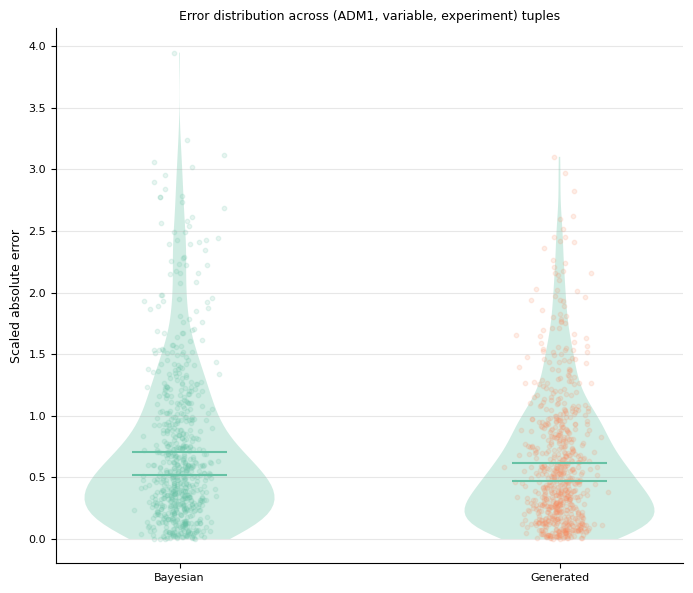

In [16]:
import matplotlib.pyplot as plt
import numpy as np

bayes_plot = violins_df.loc[violins_df["method"] == "Bayesian", "error"].dropna().values
gen_plot   = violins_df.loc[violins_df["method"] == "Generated", "error"].dropna().values

fig, ax = plt.subplots(figsize=(7, 6))

ax.violinplot(
    [bayes_plot, gen_plot],
    positions=[1, 2],
    showmeans=True,
    showmedians=True,
    showextrema=False
)

# jittered raw points
rng = np.random.default_rng(42)
x1 = 1 + rng.normal(0, 0.04, size=len(bayes_plot))
x2 = 2 + rng.normal(0, 0.04, size=len(gen_plot))

ax.scatter(x1, bayes_plot, alpha=0.15, s=10)
ax.scatter(x2, gen_plot, alpha=0.15, s=10)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Bayesian", "Generated"])
ax.set_ylabel("Scaled absolute error")
ax.set_title("Error distribution across (ADM1, variable, experiment) tuples")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
violins_df.head()

,tuple_id,experiment,adm1,variable,error,method
0,eth_micron | Addis Ababa | avg_adult_education,eth_micron,Addis Ababa,avg_adult_education,0.068424,Bayesian
1,eth_micron | Addis Ababa | fe_ai,eth_micron,Addis Ababa,fe_ai,0.930012,Bayesian
2,eth_micron | Addis Ababa | fol_ai,eth_micron,Addis Ababa,fol_ai,0.310558,Bayesian
3,eth_micron | Addis Ababa | log_exp,eth_micron,Addis Ababa,log_exp,0.050575,Bayesian
4,eth_micron | Addis Ababa | va_ai,eth_micron,Addis Ababa,va_ai,0.068382,Bayesian


In [18]:
# Aggregate to (experiment, variable) level — mean error per ADM1 group
agg_df = (
    violins_df
    .groupby(["experiment", "variable", "method"], as_index=False)["error"]
    .mean()
)

# Sort to guarantee alignment before pairing
agg_df = agg_df.sort_values(["experiment", "variable", "method"]).reset_index(drop=True)

bayes_vals = agg_df.loc[agg_df["method"] == "Bayesian"].sort_values(["experiment", "variable"])["error"].values
gen_vals   = agg_df.loc[agg_df["method"] == "Generated"].sort_values(["experiment", "variable"])["error"].values

print(f"N pairs after aggregation: {len(bayes_vals)}")
assert len(bayes_vals) == len(gen_vals), "Mismatch in number of pairs — check for missing method entries"
agg_df.head(10)

N pairs after aggregation: 40


,experiment,variable,method,error
0,eth_micron,avg_adult_education,Bayesian,0.329804
1,eth_micron,avg_adult_education,Generated,0.539526
2,eth_micron,fe_ai,Bayesian,0.846693
3,eth_micron,fe_ai,Generated,0.652508
4,eth_micron,fol_ai,Bayesian,0.673792
5,eth_micron,fol_ai,Generated,0.537900
6,eth_micron,log_exp,Bayesian,0.186946
7,eth_micron,log_exp,Generated,0.512098
8,eth_micron,va_ai,Bayesian,0.708462
9,eth_micron,va_ai,Generated,0.564123


Paired t-test: t = 2.954, p = 0.0053 (n=40 pairs)


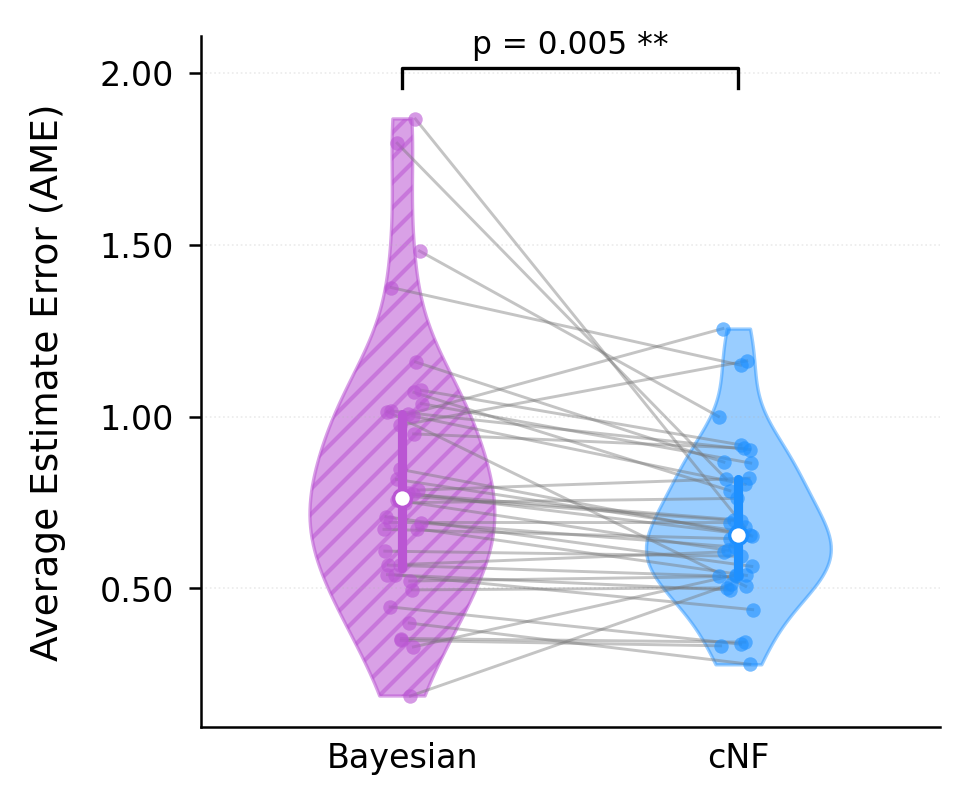

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy import stats

# ── rcParams (matching your style) ─────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
    "svg.fonttype":       "none",
})

C_BAYES = 'mediumorchid'
C_GEN   = 'DodgerBlue'

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy import stats

# ── Paired t-test ───────────────────────────────────────────────────────────
n = len(bayes_vals)
t_stat, p_val = stats.ttest_rel(bayes_vals, gen_vals)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f} (n={n} pairs)")

if p_val < 0.001:
    sig_label = "p < 0.001 ***"
elif p_val < 0.01:
    sig_label = f"p = {p_val:.3f} **"
elif p_val < 0.05:
    sig_label = f"p = {p_val:.3f} *"
else:
    sig_label = f"p = {p_val:.3f} (n.s.)"

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.2, 3.2))
fig.subplots_adjust(left=0.18, right=0.95, top=0.90, bottom=0.18)

rng = np.random.default_rng(42)

xs      = [0.0, 1.0]
colors  = [C_BAYES, C_GEN]
alphas  = [0.55, 0.45]
hatches = ["////",None]
vals_list = [bayes_vals, gen_vals]
labels  = ["Bayesian", "cNF"]

for x, vals, color, alpha, hatch in zip(xs, vals_list, colors, alphas, hatches):
    parts = ax.violinplot(
        vals, positions=[x], widths=0.55,
        showmedians=False, showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(alpha)
        pc.set_linewidth(0.8)
        if hatch:
            pc.set_hatch(hatch)

    q25, med, q75 = np.percentile(vals, [25, 50, 75])
    ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
            solid_capstyle="round", zorder=5)
    ax.scatter(x, med, color="white", s=18, zorder=6,
               linewidths=0.8, edgecolors=color)

# paired lines + points
j1 = rng.uniform(-0.06, 0.06, size=n)
j2 = rng.uniform(-0.06, 0.06, size=n)
x1 = xs[0] + j1
x2 = xs[1] + j2

for i in range(n):
    ax.plot([x1[i], x2[i]], [bayes_vals[i], gen_vals[i]],
            color="0.45", linewidth=0.7, alpha=0.42, zorder=2)

ax.scatter(x1, bayes_vals, color=C_BAYES, s=12, alpha=0.6, linewidths=0, zorder=3)
ax.scatter(x2, gen_vals,   color=C_GEN,   s=12, alpha=0.6, linewidths=0, zorder=3)

# significance bracket
y_top = max(bayes_vals.max(), gen_vals.max())
y_bracket = y_top * 1.08
ax.plot([0, 0, 1, 1], [y_bracket*0.97, y_bracket, y_bracket, y_bracket*0.97],
        color="black", linewidth=0.8)
ax.text(0.5, y_bracket * 1.01, sig_label, ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel("Average Estimate Error (AME)", fontsize=9, labelpad=8)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
ax.set_xlim(-0.6, 1.6)
ax.tick_params(axis="x", length=0)

fig.savefig("violin_bayesian_vs_generated.svg", bbox_inches="tight")
fig.savefig("violin_bayesian_vs_generated.png", bbox_inches="tight", dpi=300)
plt.show()

Paired t-test: t = 2.954, p = 0.0053 (n=40 pairs)


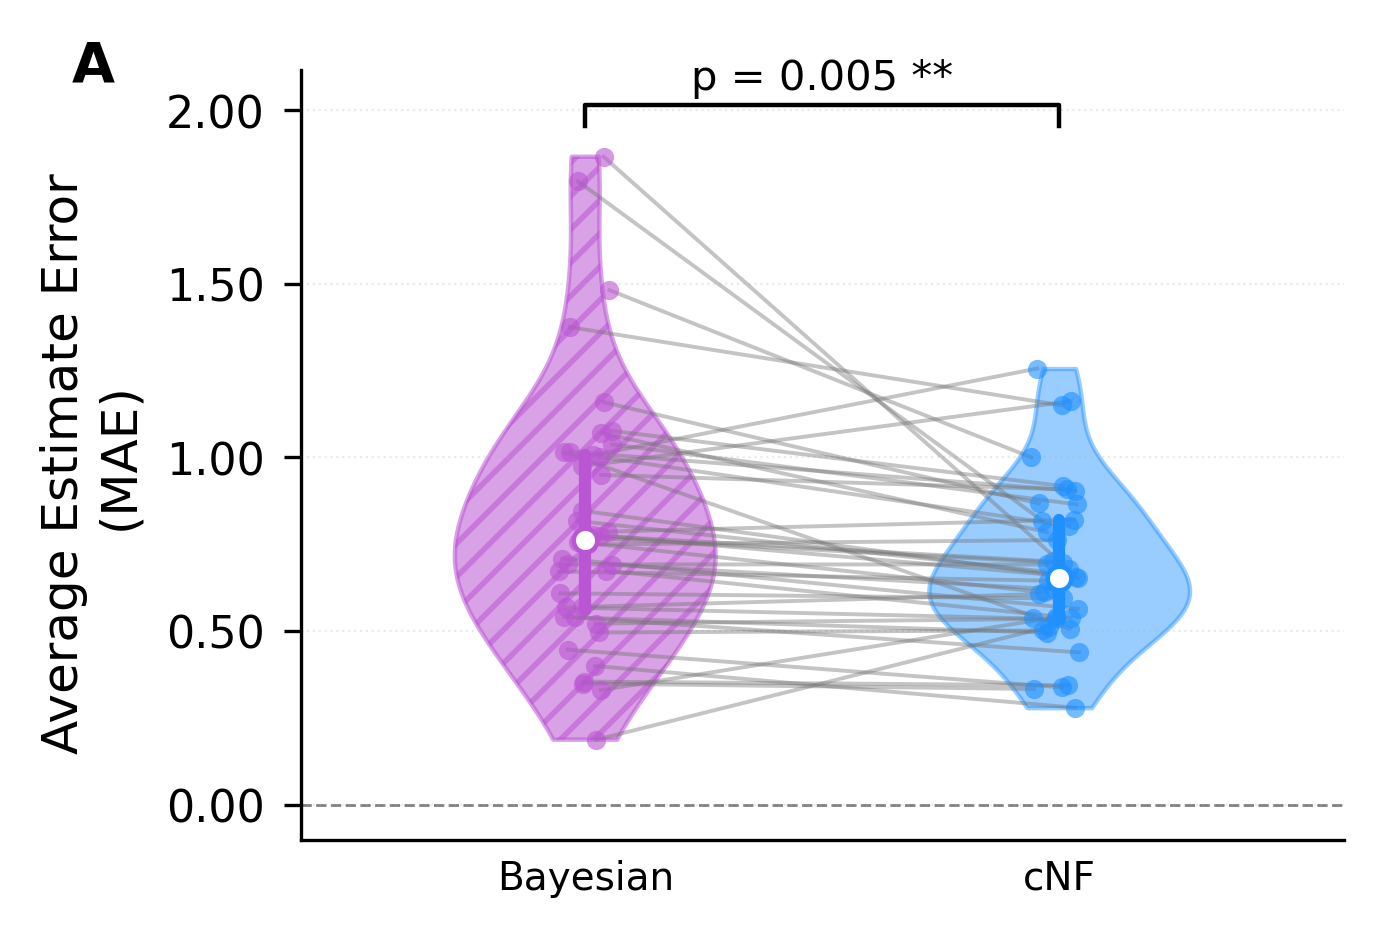

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy import stats

# ── Style — identical to other violin figure ─────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     7,
    "axes.labelweight":   "normal",
    "axes.titlesize":     7,
    "xtick.labelsize":    7,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

C_BAYES = 'mediumorchid'
C_GEN   = 'DodgerBlue'

# ── Paired t-test ─────────────────────────────────────────────────────────────
n = len(bayes_vals)
t_stat, p_val = stats.ttest_rel(bayes_vals, gen_vals)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f} (n={n} pairs)")

if p_val < 0.001:
    sig_label = "p < 0.001 ***"
elif p_val < 0.01:
    sig_label = f"p = {p_val:.3f} **"
elif p_val < 0.05:
    sig_label = f"p = {p_val:.3f} *"
else:
    sig_label = f"p = {p_val:.3f} (n.s.)"

# ── Figure — same width as other violin, single panel height ─────────────────
fig, ax = plt.subplots(figsize=(3.3, 2.6))
fig.subplots_adjust(left=0.18, right=0.97, top=0.88, bottom=0.14)

rng     = np.random.default_rng(42)
xs      = [0.0, 1.0]
colors  = [C_BAYES, C_GEN]
alphas  = [0.55, 0.45]
hatches = ["////", None]
vals_list = [bayes_vals, gen_vals]
labels    = ["Bayesian", "cNF"]

for x, vals, color, alpha, hatch in zip(xs, vals_list, colors, alphas, hatches):
    parts = ax.violinplot(
        vals, positions=[x], widths=0.55,
        showmedians=False, showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(alpha)
        pc.set_linewidth(0.8)
        if hatch:
            pc.set_hatch(hatch)

    q25, med, q75 = np.percentile(vals, [25, 50, 75])
    ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
            solid_capstyle="round", zorder=5)
    ax.scatter(x, med, color="white", s=18, zorder=6,
               linewidths=0.8, edgecolors=color)

# paired lines + points
j1 = rng.uniform(-0.06, 0.06, size=n)
j2 = rng.uniform(-0.06, 0.06, size=n)
x1 = xs[0] + j1
x2 = xs[1] + j2

for i in range(n):
    ax.plot([x1[i], x2[i]], [bayes_vals[i], gen_vals[i]],
            color="0.45", linewidth=0.7, alpha=0.42, zorder=2)

ax.scatter(x1, bayes_vals, color=C_BAYES, s=12, alpha=0.6, linewidths=0, zorder=3)
ax.scatter(x2, gen_vals,   color=C_GEN,   s=12, alpha=0.6, linewidths=0, zorder=3)

ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

# significance bracket
y_top     = max(bayes_vals.max(), gen_vals.max())
y_bracket = y_top * 1.08
ax.plot([0, 0, 1, 1],
        [y_bracket * 0.97, y_bracket, y_bracket, y_bracket * 0.97],
        color="black", linewidth=0.8)
ax.text(0.5, y_bracket * 1.01, sig_label,
        ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel("Average Estimate Error \n(MAE)", fontsize=9, labelpad=4)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
ax.set_xlim(-0.6, 1.6)
ax.tick_params(axis="x", length=0)

# panel letter
ax.text(
    -0.22, 1.04, "A",
    transform=ax.transAxes,
    fontsize=10, fontweight="bold",
    va="top", ha="left"
)

# ── Save ─────────────────────────────────────────────────────────────────────
fig.savefig("violin_bayesian_vs_generated.png", bbox_inches="tight", dpi=400)
fig.savefig("violin_bayesian_vs_generated.pdf", bbox_inches="tight")
fig.savefig("violin_bayesian_vs_generated.svg", bbox_inches="tight")
plt.show()

In [21]:
from scipy.stats import wilcoxon, ttest_rel

paired_df = plot_base[[
    "tuple_id",
    "bayes_abs_err_std",
    "gen_abs_err_std"
]].dropna().copy()

paired_df["diff_gen_minus_bayes"] = (
    paired_df["gen_abs_err_std"] - paired_df["bayes_abs_err_std"]
)

print("Number of paired observations:", len(paired_df))

# Wilcoxon signed-rank test
wilcox_res = wilcoxon(
    paired_df["gen_abs_err_std"],
    paired_df["bayes_abs_err_std"],
    alternative="two-sided",
    zero_method="wilcox"
)

# paired t-test (secondary / optional)
ttest_res = ttest_rel(
    paired_df["gen_abs_err_std"],
    paired_df["bayes_abs_err_std"],
    nan_policy="omit"
)

summary_stats = pd.DataFrame({
    "metric": [
        "n_pairs",
        "bayes_mean",
        "gen_mean",
        "bayes_median",
        "gen_median",
        "mean_diff_gen_minus_bayes",
        "median_diff_gen_minus_bayes",
        "wilcoxon_stat",
        "wilcoxon_pvalue",
        "paired_t_stat",
        "paired_t_pvalue",
    ],
    "value": [
        len(paired_df),
        paired_df["bayes_abs_err_std"].mean(),
        paired_df["gen_abs_err_std"].mean(),
        paired_df["bayes_abs_err_std"].median(),
        paired_df["gen_abs_err_std"].median(),
        paired_df["diff_gen_minus_bayes"].mean(),
        paired_df["diff_gen_minus_bayes"].median(),
        wilcox_res.statistic,
        wilcox_res.pvalue,
        ttest_res.statistic,
        ttest_res.pvalue,
    ]
})

summary_stats

Number of paired observations: 693


,metric,value
0,n_pairs,693.000000
1,bayes_mean,0.708716
2,gen_mean,0.616106
3,bayes_median,0.522574
4,gen_median,0.468109
5,mean_diff_gen_minus_bayes,-0.092611
6,median_diff_gen_minus_bayes,-0.048394
7,wilcoxon_stat,97500.000000
8,wilcoxon_pvalue,0.000016
9,paired_t_stat,-4.853649


In [22]:
diff = paired_df["diff_gen_minus_bayes"].dropna().values

effect_summary = pd.DataFrame({
    "metric": [
        "mean_diff_gen_minus_bayes",
        "median_diff_gen_minus_bayes",
        "pct_bayes_better",
        "pct_gen_better",
        "pct_tie"
    ],
    "value": [
        np.mean(diff),
        np.median(diff),
        np.mean(diff > 0),   # Gen error > Bayes error => Bayes better
        np.mean(diff < 0),   # Gen better
        np.mean(diff == 0)
    ]
})

effect_summary

,metric,value
0,mean_diff_gen_minus_bayes,-0.092611
1,median_diff_gen_minus_bayes,-0.048394
2,pct_bayes_better,0.428571
3,pct_gen_better,0.571429
4,pct_tie,0.000000


Random point seed: 7

Selected random experiment-variable point:
experiment           lka_vam
variable          log_income
bayes_err_mean      0.608467
cnf_err_mean        0.593665
improvement         0.014802
n_adm1                     9
Name: 17, dtype: object

Highest-improvement ADM1:
{'adm1': 'Western', 'adm1_norm': 'western', 'absolute_improvement': 0.5404731978197446}

Lowest-improvement ADM1:
{'adm1': 'Southern', 'adm1_norm': 'southern', 'absolute_improvement': -0.2305313983989803}


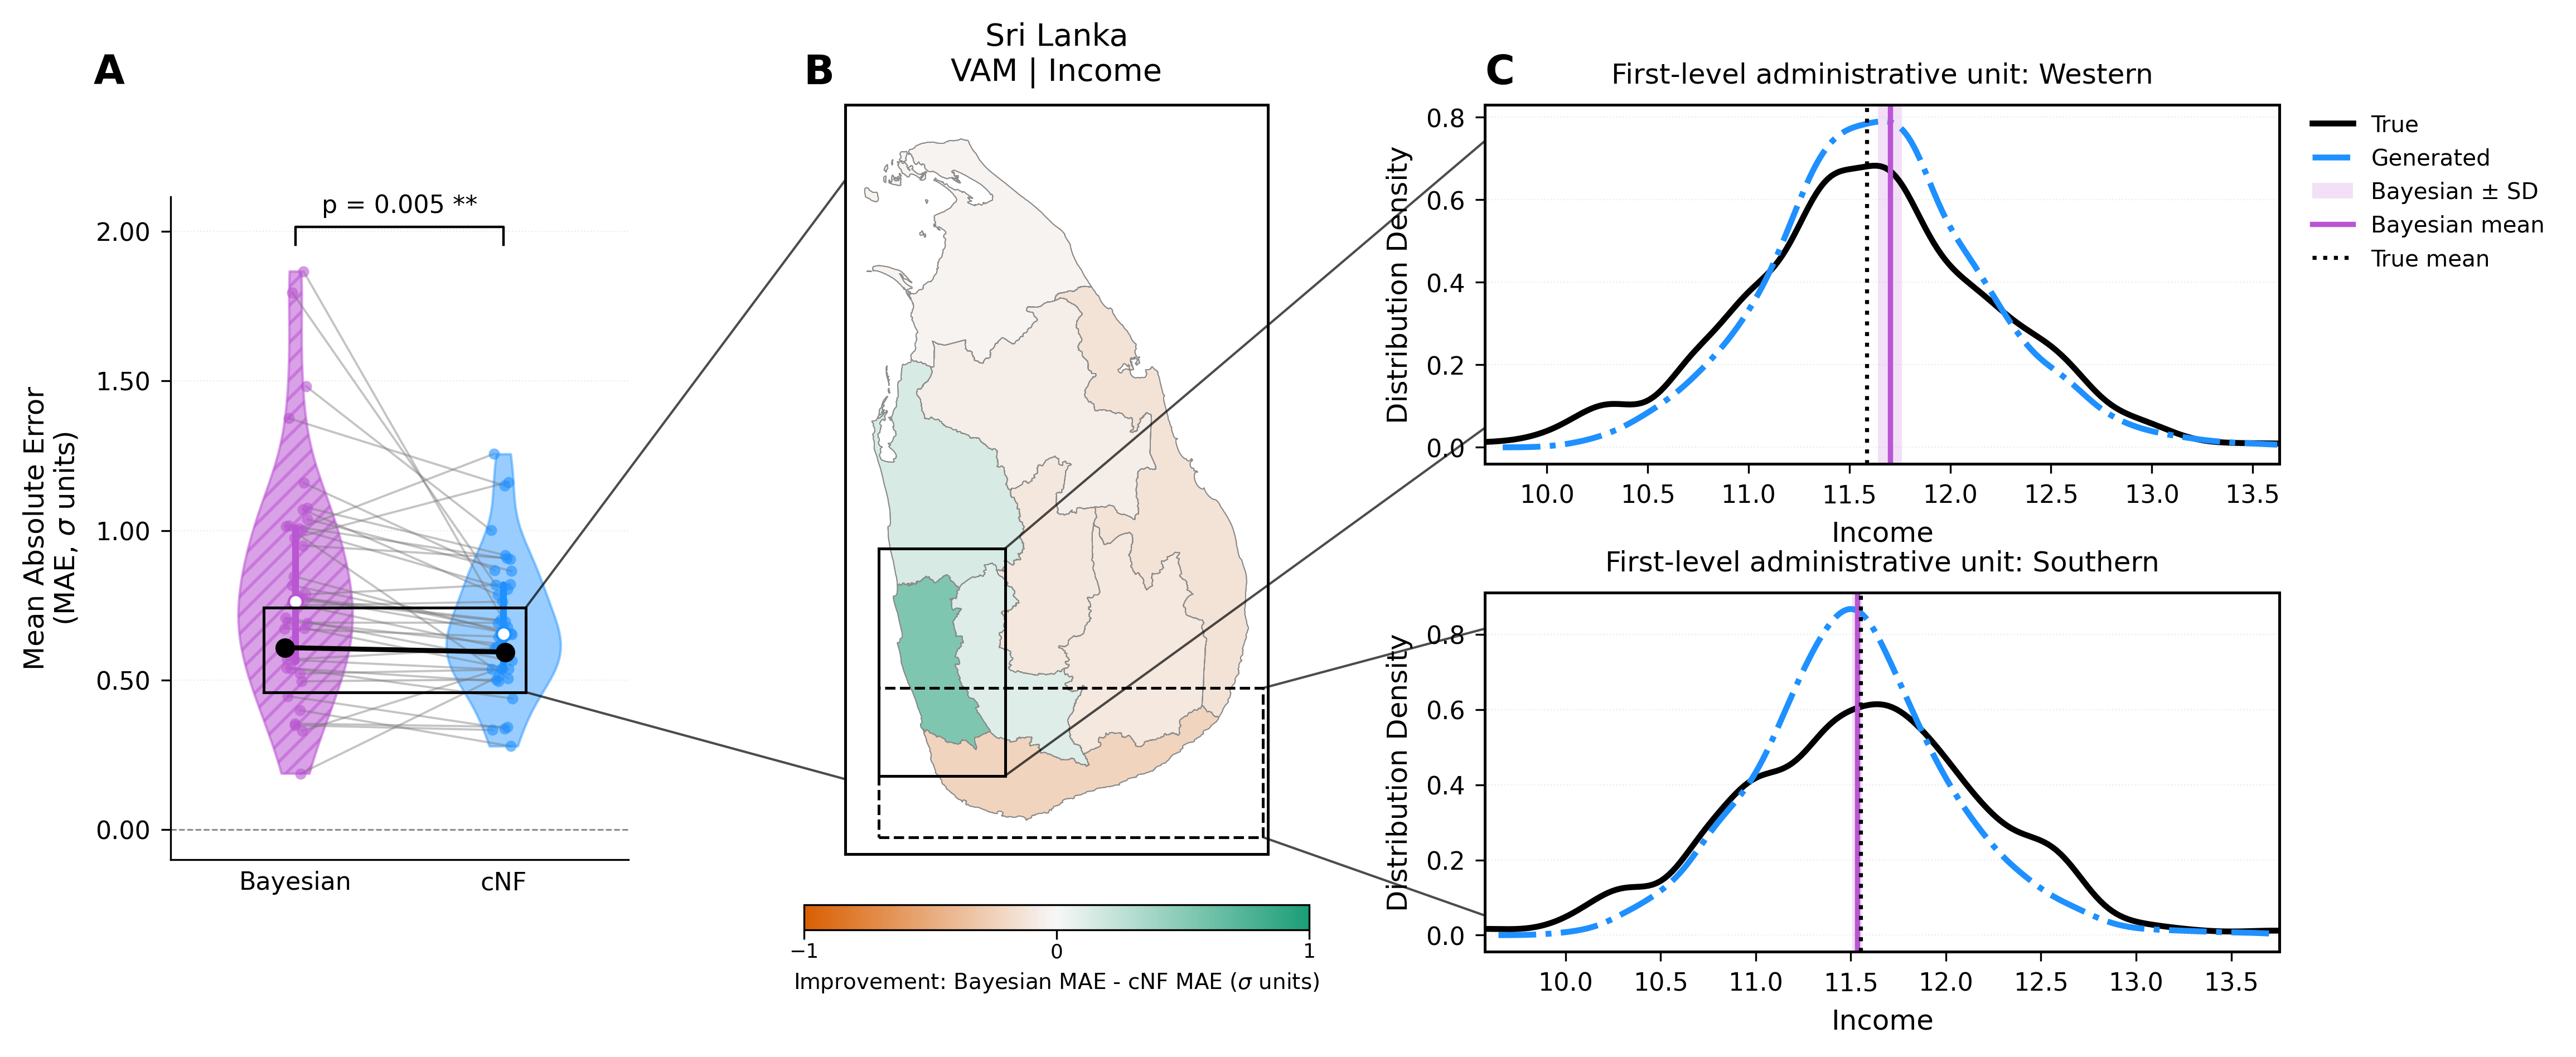

In [23]:
# =============================================================================
# Complete self-contained plotting cell
#
# Requirements:
#   - `results_eval` must already exist in the notebook.
#   - It must contain at least:
#       experiment, variable, adm1 or adm1_norm,
#       true_mean, bayes_mean, gen_mean,
#       bayes_abs_err_std, gen_abs_err_std
#
# Figure:
#   Panel A: paired violin with one random experiment-variable point highlighted
#   Panel B: ADM1 absolute improvement map for that random point
#   Panel C: two density plots:
#       top    = ADM1 with highest absolute improvement
#       bottom = ADM1 with lowest absolute improvement
#
# Improvement convention:
#   absolute improvement = Bayesian_error - cNF_error
#
# Therefore:
#   positive -> cNF has LOWER error than Bayesian, so cNF is better
#   negative -> cNF has HIGHER error than Bayesian, so cNF is worse
# =============================================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle, ConnectionPatch
from scipy import stats
from scipy.stats import gaussian_kde

import geopandas as gpd
from shapely import wkt


# -----------------------------------------------------------------------------
# Settings
# -----------------------------------------------------------------------------

EXPERIMENT_ROOT = "/data/shared/fsibilla/clean_code/Q1/experiments"

TRAIN_ID = 1
SEED_IDS = [1, 2, 3, 4, 5]

RANDOM_POINT_SEED = 7

OUT_PREFIX = f"violin_one_map_two_densities_seed_{RANDOM_POINT_SEED}_absolute"

# Density x-axis: moderately zoomed out
DENSITY_Q_LOW = 0.005
DENSITY_Q_HIGH = 0.995
DENSITY_PAD_FRAC = 0.10
DENSITY_MIN_WIDTH = 2.5
DENSITY_MAX_WIDTH = 16.0

C_BAYES = "mediumorchid"
C_GEN = "DodgerBlue"

# Reference-style map colors:
# orange/brown = worse, white = neutral, green = better.
IMPROVEMENT_CMAP = LinearSegmentedColormap.from_list(
    "improvement_orange_white_green",
    ["#d95f02", "#f7f7f7", "#1b9e77"],
    N=256
)

DISPLAY_LABELS = {
    "avg_adult_education": "Education",
    "fe_ai":        "Iron",
    "fol_ai":       "Folate",
    "log_exp":      "Expenditures",
    "va_ai":        "Vitamin A",
    "vb12_ai":      "Vitamin B12",
    "zn_ai":        "Zinc",
    "fe_mg":        "Iron",
    "folate_mcg":   "Folate",
    "vita_rae_mcg": "Vitamin A",
    "vitb12_mcg":   "Vitamin B12",
    "zn_mg":        "Zinc",
    "FCS":          "FCS",
    "FES":          "FES",
    "education_score": "Education",
    "log_income":   "Income",
    "rCSI":         "rCSI",
    "space_per_person": "Space pp",
    "FGHIron":      "Iron",
    "FGProtein":    "Protein",
    "FGVitA":       "Vitamin A",
    "wscore":       "Wealth Score",
    "log_exp_pp":   "Expenditures pp",
    "eth_micron":   "Ethiopia\nESS",
    "lka_micron":   "Sri Lanka\nHIES",
    "lka_vam":      "Sri Lanka\nVAM",
    "moz_vam":      "Mozambique\nVAM",
    "nga_micron":   "Nigeria\nNLSS",
    "nga_mics":     "Nigeria\nMICS",
    "yem_mvam":     "Yemen\nmVAM",
    "zwe_mics":     "Zimbabwe\nMICS",
}


# -----------------------------------------------------------------------------
# Helper functions
# -----------------------------------------------------------------------------

def _norm_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9]+", "", x)
    return x


def _safe_improvement(bayes_err, gen_err):
    """
    Absolute improvement:

        Bayesian error - cNF error

    positive -> cNF better
    negative -> cNF worse
    """
    bayes_err = np.asarray(bayes_err, dtype=float)
    gen_err = np.asarray(gen_err, dtype=float)

    return np.where(
        np.isfinite(bayes_err) & np.isfinite(gen_err),
        bayes_err - gen_err,
        np.nan
    )


def _find_col(df, candidates, required=True, label="column"):
    for c in candidates:
        if c in df.columns:
            return c

    if required:
        raise ValueError(
            f"Could not find {label}. Tried: {candidates}\n"
            f"Available columns include:\n{list(df.columns)[:120]}"
        )

    return None


def _read_csv_header(path):
    return list(pd.read_csv(path, nrows=0).columns)


def _experiment_country_code(experiment):
    return str(experiment).split("_")[0].lower()


def _seed_paths(experiment, train_id=TRAIN_ID, seed_id=1):
    """
    Non-scaled files.

    Full data:
        /data/shared/fsibilla/clean_code/Q1/experiments/{experiment}/full.csv

    Generated:
        /data/shared/fsibilla/clean_code/Q1/experiments/{experiment}/results/train_1_scaled/seed_1_scaled/generated_pool_1_seed1.csv
    """
    seed_dir = os.path.join(
        EXPERIMENT_ROOT,
        str(experiment),
        "results",
        f"train_{train_id}_scaled",
        f"seed_{seed_id}_scaled"
    )

    full_path = os.path.join(
        EXPERIMENT_ROOT,
        str(experiment),
        "full.csv"
    )

    gen_path = os.path.join(
        seed_dir,
        f"generated_pool_{train_id}_seed{seed_id}.csv"
    )

    return full_path, gen_path


def load_adm1_geometries_for_experiment(
    experiment,
    experiment_root=EXPERIMENT_ROOT,
    adm1_name_col="adm1name",
    adm1_geom_col="adm1geometry",
):
    full_path = os.path.join(experiment_root, str(experiment), "full.csv")

    if not os.path.exists(full_path):
        raise FileNotFoundError(
            f"Could not find full.csv for experiment '{experiment}' at:\n{full_path}"
        )

    header = _read_csv_header(full_path)

    if adm1_name_col not in header:
        raise ValueError(
            f"Column '{adm1_name_col}' not found in {full_path}.\n"
            f"Available columns include:\n{header[:120]}"
        )

    if adm1_geom_col not in header:
        raise ValueError(
            f"Column '{adm1_geom_col}' not found in {full_path}.\n"
            f"Available columns include:\n{header[:120]}"
        )

    geo_df = pd.read_csv(
        full_path,
        usecols=[adm1_name_col, adm1_geom_col],
        dtype={adm1_name_col: str, adm1_geom_col: str}
    )

    geo_df = (
        geo_df
        .dropna(subset=[adm1_name_col, adm1_geom_col])
        .drop_duplicates(subset=[adm1_name_col])
        .copy()
    )

    geo_df["adm1_norm"] = geo_df[adm1_name_col].map(_norm_name)
    geo_df["geometry"] = geo_df[adm1_geom_col].map(wkt.loads)

    gdf = gpd.GeoDataFrame(
        geo_df[[adm1_name_col, "adm1_norm", "geometry"]],
        geometry="geometry",
        crs="EPSG:4326"
    )

    gdf = gdf.rename(columns={adm1_name_col: "adm1_geometry_name"})

    return gdf


def make_adm1_map_data(selected_row):
    experiment = selected_row["experiment"]
    variable = selected_row["variable"]

    sub = results_eval[
        (results_eval["experiment"].astype(str) == str(experiment)) &
        (results_eval["variable"].astype(str) == str(variable))
    ].copy()

    sub = sub.dropna(subset=["bayes_abs_err_std", "gen_abs_err_std"]).copy()

    sub["improvement"] = _safe_improvement(
        sub["bayes_abs_err_std"],
        sub["gen_abs_err_std"]
    )

    if "adm1_norm" not in sub.columns:
        if "adm1" not in sub.columns:
            raise ValueError("results_eval must contain either 'adm1_norm' or 'adm1'.")
        sub["adm1_norm"] = sub["adm1"].map(_norm_name)
    else:
        sub["adm1_norm"] = sub["adm1_norm"].map(_norm_name)

    agg_dict = {
        "improvement": ("improvement", "mean"),
        "bayes_error": ("bayes_abs_err_std", "mean"),
        "cnf_error": ("gen_abs_err_std", "mean"),
        "true_mean": ("true_mean", "mean"),
        "bayes_mean": ("bayes_mean", "mean"),
        "gen_mean": ("gen_mean", "mean"),
        "n_rows": ("improvement", "size"),
    }

    bayes_sd_col = _find_col(
        sub,
        [
            "bayes_sd",
            "bayes_std",
            "bayes_stddev",
            "bayes_sigma",
            "posterior_sd",
            "post_sd"
        ],
        required=False,
        label="Bayesian standard deviation column"
    )

    if bayes_sd_col is not None:
        agg_dict["bayes_sd"] = (bayes_sd_col, "mean")

    map_values = (
        sub
        .groupby("adm1_norm", as_index=False)
        .agg(**agg_dict)
    )

    adm1_gdf = load_adm1_geometries_for_experiment(experiment)

    map_gdf = adm1_gdf.merge(
        map_values,
        on="adm1_norm",
        how="left"
    )

    return map_gdf


def _filter_adm1(df, adm1_norm_value):
    adm1_col = _find_col(
        df,
        [
            "adm1_norm",
            "adm1name",
            "adm1",
            "ADM1",
            "ADM1_EN",
            "admin1Name",
            "region"
        ],
        required=True,
        label="ADM1 column"
    )

    tmp = df.copy()
    tmp["_adm1_norm_tmp"] = tmp[adm1_col].map(_norm_name)

    return tmp[tmp["_adm1_norm_tmp"] == adm1_norm_value].copy()


def _mean_density_over_seeds(seed_value_arrays, gridsize=300):
    clean_arrays = []

    for values in seed_value_arrays:
        values = pd.Series(values).dropna().astype(float).values
        values = values[np.isfinite(values)]
        if len(values) >= 2:
            clean_arrays.append(values)

    if len(clean_arrays) == 0:
        return None, None

    all_values = np.concatenate(clean_arrays)

    vmin = np.nanmin(all_values)
    vmax = np.nanmax(all_values)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return None, None

    if vmin == vmax:
        pad = abs(vmin) * 0.05 if vmin != 0 else 0.1
    else:
        pad = 0.08 * (vmax - vmin)

    x = np.linspace(vmin - pad, vmax + pad, gridsize)

    densities = []

    for values in clean_arrays:
        try:
            kde = gaussian_kde(values)
            densities.append(kde(x))
        except Exception:
            pass

    if len(densities) == 0:
        return None, None

    y = np.mean(np.vstack(densities), axis=0)

    return x, y


def make_distribution_data_for_panel_c(selected_point, selected_adm1_norm):
    experiment = str(selected_point["experiment"])
    variable = str(selected_point["variable"])

    adm1_candidates = [
        "adm1_norm",
        "adm1name",
        "adm1",
        "ADM1",
        "ADM1_EN",
        "admin1Name",
        "region"
    ]

    full_seed_arrays = []
    gen_seed_arrays = []

    used_full_paths = []
    used_gen_paths = []

    for seed_id in SEED_IDS:
        full_path, gen_path = _seed_paths(
            experiment,
            train_id=TRAIN_ID,
            seed_id=seed_id
        )

        if not (os.path.exists(full_path) and os.path.exists(gen_path)):
            continue

        full_header = _read_csv_header(full_path)
        gen_header = _read_csv_header(gen_path)

        if variable not in full_header:
            continue
        if variable not in gen_header:
            continue

        full_adm1_col = next((c for c in adm1_candidates if c in full_header), None)
        gen_adm1_col = next((c for c in adm1_candidates if c in gen_header), None)

        if full_adm1_col is None or gen_adm1_col is None:
            continue

        full_df = pd.read_csv(full_path, usecols=[full_adm1_col, variable])
        gen_df = pd.read_csv(gen_path, usecols=[gen_adm1_col, variable])

        full_sub = _filter_adm1(full_df, selected_adm1_norm)
        gen_sub = _filter_adm1(gen_df, selected_adm1_norm)

        full_values = pd.to_numeric(full_sub[variable], errors="coerce").dropna().values
        gen_values = pd.to_numeric(gen_sub[variable], errors="coerce").dropna().values

        if len(full_values) > 0:
            full_seed_arrays.append(full_values)
            used_full_paths.append(full_path)

        if len(gen_values) > 0:
            gen_seed_arrays.append(gen_values)
            used_gen_paths.append(gen_path)

    if len(full_seed_arrays) == 0:
        raise ValueError(f"No usable full-data arrays found for ADM1 {selected_adm1_norm}.")
    if len(gen_seed_arrays) == 0:
        raise ValueError(f"No usable generated arrays found for ADM1 {selected_adm1_norm}.")

    full_x, full_y = _mean_density_over_seeds(full_seed_arrays)
    gen_x, gen_y = _mean_density_over_seeds(gen_seed_arrays)

    return {
        "variable": variable,
        "full_paths": used_full_paths,
        "gen_paths": used_gen_paths,
        "full_seed_arrays": full_seed_arrays,
        "gen_seed_arrays": gen_seed_arrays,
        "full_density_x": full_x,
        "full_density_y": full_y,
        "gen_density_x": gen_x,
        "gen_density_y": gen_y,
        "n_full_seeds": len(full_seed_arrays),
        "n_gen_seeds": len(gen_seed_arrays),
        "n_full_total": sum(len(v) for v in full_seed_arrays),
        "n_gen_total": sum(len(v) for v in gen_seed_arrays),
        "full_pooled_values": np.concatenate(full_seed_arrays),
        "gen_pooled_values": np.concatenate(gen_seed_arrays),
    }


def prepare_panel_c_bundle(selected_point, selected_adm1_row):
    selected_adm1_norm = selected_adm1_row["adm1_norm"]

    dist_data = make_distribution_data_for_panel_c(selected_point, selected_adm1_norm)

    eval_sub = results_eval[
        (results_eval["experiment"].astype(str) == str(selected_point["experiment"])) &
        (results_eval["variable"].astype(str) == str(selected_point["variable"]))
    ].copy()

    if "adm1_norm" not in eval_sub.columns:
        eval_sub["adm1_norm"] = eval_sub["adm1"].map(_norm_name)
    else:
        eval_sub["adm1_norm"] = eval_sub["adm1_norm"].map(_norm_name)

    eval_sub = eval_sub[eval_sub["adm1_norm"] == selected_adm1_norm].copy()

    if eval_sub.empty:
        raise ValueError(f"Could not find ADM1 {selected_adm1_norm} in results_eval.")

    bayes_mu = eval_sub["bayes_mean"].mean()

    bayes_sd_col = _find_col(
        eval_sub,
        [
            "bayes_sd",
            "bayes_std",
            "bayes_stddev",
            "bayes_sigma",
            "posterior_sd",
            "post_sd"
        ],
        required=False,
        label="Bayesian standard deviation column"
    )

    bayes_sd = eval_sub[bayes_sd_col].mean() if bayes_sd_col is not None else np.nan
    true_mean = np.nanmean(dist_data["full_pooled_values"])

    return {
        "adm1_name": selected_adm1_row["adm1_geometry_name"],
        "adm1_norm": selected_adm1_norm,
        "improvement": selected_adm1_row["improvement"],
        "geometry": selected_adm1_row["geometry"],
        "dist_data": dist_data,
        "bayes_mu": bayes_mu,
        "bayes_sd": bayes_sd,
        "true_mean": true_mean,
        "variable": selected_point["variable"],
    }


def geom_zoom_bounds(geom, pad_frac=0.15):
    xmin, ymin, xmax, ymax = geom.bounds
    dx = xmax - xmin
    dy = ymax - ymin
    pad_x = pad_frac * dx if dx > 0 else 0.1
    pad_y = pad_frac * dy if dy > 0 else 0.1
    return xmin - pad_x, ymin - pad_y, xmax + pad_x, ymax + pad_y


def density_xlim_for_bundle(bundle):
    """
    Choose readable x-range around the central mass of the plotted empirical
    distributions: true + generated.
    """
    dist_data = bundle["dist_data"]

    values = np.concatenate([
        dist_data["full_pooled_values"],
        dist_data["gen_pooled_values"],
    ])

    values = pd.Series(values).dropna().astype(float).values
    values = values[np.isfinite(values)]

    if len(values) < 2:
        return (-1, 1)

    lo = np.quantile(values, DENSITY_Q_LOW)
    hi = np.quantile(values, DENSITY_Q_HIGH)

    width = hi - lo

    if not np.isfinite(width) or width <= 0:
        center = np.nanmedian(values)
        return (center - 1, center + 1)

    pad = DENSITY_PAD_FRAC * width
    lo -= pad
    hi += pad
    width = hi - lo

    center = 0.5 * (lo + hi)

    if width < DENSITY_MIN_WIDTH:
        lo = center - DENSITY_MIN_WIDTH / 2
        hi = center + DENSITY_MIN_WIDTH / 2

    if width > DENSITY_MAX_WIDTH:
        lo = center - DENSITY_MAX_WIDTH / 2
        hi = center + DENSITY_MAX_WIDTH / 2

    return lo, hi


def _plot_density_curve_clipped(ax, x, y, xlim, **kwargs):
    if x is None or y is None:
        return None

    mask = (x >= xlim[0]) & (x <= xlim[1])

    if mask.sum() >= 2:
        line, = ax.plot(x[mask], y[mask], **kwargs)
        return line

    return None


def plot_panel_c(ax, bundle, title_text, show_legend=True):
    dist_data = bundle["dist_data"]
    bayes_mu = bundle["bayes_mu"]
    bayes_sd = bundle["bayes_sd"]
    true_mean = bundle["true_mean"]

    varname = str(bundle["variable"])
    xlabel = DISPLAY_LABELS.get(varname, varname)

    xlim = density_xlim_for_bundle(bundle)

    _plot_density_curve_clipped(
        ax,
        dist_data["full_density_x"],
        dist_data["full_density_y"],
        xlim=xlim,
        linewidth=1.9,
        linestyle="-",
        color="black",
        label="True"
    )

    _plot_density_curve_clipped(
        ax,
        dist_data["gen_density_x"],
        dist_data["gen_density_y"],
        xlim=xlim,
        linewidth=1.9,
        linestyle="-.",
        color=C_GEN,
        label="Generated"
    )

    if np.isfinite(bayes_mu) and np.isfinite(bayes_sd):
        left = bayes_mu - bayes_sd
        right = bayes_mu + bayes_sd

        if right >= xlim[0] and left <= xlim[1]:
            ax.axvspan(
                max(left, xlim[0]),
                min(right, xlim[1]),
                color=C_BAYES,
                alpha=0.18,
                linewidth=0,
                label="Bayesian ± SD"
            )

    if np.isfinite(bayes_mu) and xlim[0] <= bayes_mu <= xlim[1]:
        ax.axvline(
            bayes_mu,
            color=C_BAYES,
            linewidth=1.7,
            linestyle="-",
            label="Bayesian mean"
        )

    if np.isfinite(true_mean) and xlim[0] <= true_mean <= xlim[1]:
        ax.axvline(
            true_mean,
            color="black",
            linewidth=1.3,
            linestyle=":",
            label="True mean"
        )

    ax.set_xlim(*xlim)
    ax.set_title(title_text, fontsize=9, pad=7)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Distribution Density", fontsize=9)
    ax.tick_params(axis="both", labelsize=8)
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")

    if show_legend:
        ax.legend(
            fontsize=7.3,
            loc="upper left",
            bbox_to_anchor=(1.03, 1.00),
            handlelength=1.8,
            borderaxespad=0.0,
            frameon=False
        )

    frame = Rectangle(
        (0, 0),
        1,
        1,
        transform=ax.transAxes,
        fill=False,
        edgecolor="black",
        linewidth=0.9,
        linestyle="-",
        clip_on=False,
        zorder=15
    )
    ax.add_patch(frame)


# -----------------------------------------------------------------------------
# 1. Aggregate to experiment-variable level and select one random point
# -----------------------------------------------------------------------------

adm1_count_col = "adm1_norm" if "adm1_norm" in results_eval.columns else "adm1"

point_base = results_eval.dropna(
    subset=["bayes_abs_err_std", "gen_abs_err_std"]
).copy()

point_base["adm1_absolute_improvement"] = _safe_improvement(
    point_base["bayes_abs_err_std"],
    point_base["gen_abs_err_std"]
)

point_df = (
    point_base
    .dropna(subset=["adm1_absolute_improvement"])
    .groupby(["experiment", "variable"], as_index=False)
    .agg(
        bayes_err_mean=("bayes_abs_err_std", "mean"),
        cnf_err_mean=("gen_abs_err_std", "mean"),
        improvement=("adm1_absolute_improvement", "mean"),
        n_adm1=(adm1_count_col, "nunique")
    )
)

point_df = point_df.dropna(subset=["improvement"]).copy()

selected_point = point_df.sample(
    n=1,
    random_state=RANDOM_POINT_SEED,
    replace=False
).iloc[0].copy()

print("Random point seed:", RANDOM_POINT_SEED)
print("\nSelected random experiment-variable point:")
print(
    selected_point[
        ["experiment", "variable", "bayes_err_mean", "cnf_err_mean", "improvement", "n_adm1"]
    ]
)


# -----------------------------------------------------------------------------
# 2. Prepare Panel A values
# -----------------------------------------------------------------------------

plot_base = results_eval.dropna(
    subset=["bayes_abs_err_std", "gen_abs_err_std"]
).copy()

agg_df = (
    plot_base
    .groupby(["experiment", "variable"], as_index=False)
    .agg(
        bayes_err_mean=("bayes_abs_err_std", "mean"),
        cnf_err_mean=("gen_abs_err_std", "mean")
    )
    .sort_values(["experiment", "variable"])
    .reset_index(drop=True)
)

bayes_vals = agg_df["bayes_err_mean"].values
gen_vals = agg_df["cnf_err_mean"].values

n = len(agg_df)

t_stat, p_val = stats.ttest_rel(bayes_vals, gen_vals)

if p_val < 0.001:
    sig_label = "p < 0.001 ***"
elif p_val < 0.01:
    sig_label = f"p = {p_val:.3f} **"
elif p_val < 0.05:
    sig_label = f"p = {p_val:.3f} *"
else:
    sig_label = f"p = {p_val:.3f} (n.s.)"


def _row_matches_point(df, selected):
    return (
        (df["experiment"].astype(str) == str(selected["experiment"])) &
        (df["variable"].astype(str) == str(selected["variable"]))
    )


selected_idx = np.where(_row_matches_point(agg_df, selected_point))[0][0]


# -----------------------------------------------------------------------------
# 3. Prepare map and density bundles
# -----------------------------------------------------------------------------

selected_map_gdf = make_adm1_map_data(selected_point)

# Fixed colorbar range
vmin, vmax = -1.0, 1.0

highest_row = selected_map_gdf.dropna(subset=["improvement"]).sort_values(
    "improvement",
    ascending=False
).iloc[0].copy()

lowest_row = selected_map_gdf.dropna(subset=["improvement"]).sort_values(
    "improvement",
    ascending=True
).iloc[0].copy()

bundle_high = prepare_panel_c_bundle(selected_point, highest_row)
bundle_low = prepare_panel_c_bundle(selected_point, lowest_row)

print("\nHighest-improvement ADM1:")
print({
    "adm1": highest_row["adm1_geometry_name"],
    "adm1_norm": highest_row["adm1_norm"],
    "absolute_improvement": highest_row["improvement"],
})

print("\nLowest-improvement ADM1:")
print({
    "adm1": lowest_row["adm1_geometry_name"],
    "adm1_norm": lowest_row["adm1_norm"],
    "absolute_improvement": lowest_row["improvement"],
})


# -----------------------------------------------------------------------------
# 4. Plot full figure
# -----------------------------------------------------------------------------

plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          9,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    7.3,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

fig = plt.figure(figsize=(11.6, 5.2))

outer = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[0.95, 1.05, 1.65],
    left=0.065,
    right=0.88,
    bottom=0.13,
    top=0.86,
    wspace=0.30
)

axA = fig.add_subplot(outer[0, 0])
axB = fig.add_subplot(outer[0, 1])

gsC = outer[0, 2].subgridspec(2, 1, hspace=0.36)
axC_top = fig.add_subplot(gsC[0, 0])
axC_bot = fig.add_subplot(gsC[1, 0])

letter_y = 0.905
fig.text(axA.get_position().x0 - 0.03, letter_y, "A", fontsize=13, fontweight="bold", va="top", ha="left")
fig.text(axB.get_position().x0,        letter_y, "B", fontsize=13, fontweight="bold", va="top", ha="left")
fig.text(axC_top.get_position().x0,    letter_y, "C", fontsize=13, fontweight="bold", va="top", ha="left")


# -------------------------
# Panel A
# -------------------------

rng = np.random.default_rng(42)

xs = [0.0, 1.0]
vals_list = [bayes_vals, gen_vals]
colors = [C_BAYES, C_GEN]
alphas = [0.55, 0.45]
hatches = ["////", None]
labels = ["Bayesian", "cNF"]

for x, vals, color, alpha, hatch in zip(xs, vals_list, colors, alphas, hatches):
    parts = axA.violinplot(
        vals,
        positions=[x],
        widths=0.55,
        showmedians=False,
        showextrema=False
    )

    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(alpha)
        pc.set_linewidth(0.8)
        if hatch:
            pc.set_hatch(hatch)

    q25, med, q75 = np.percentile(vals, [25, 50, 75])

    axA.plot(
        [x, x],
        [q25, q75],
        color=color,
        linewidth=2.2,
        solid_capstyle="round",
        zorder=5
    )

    axA.scatter(
        x,
        med,
        color="white",
        s=20,
        zorder=6,
        linewidths=0.8,
        edgecolors=color
    )

j1 = rng.uniform(-0.06, 0.06, size=n)
j2 = rng.uniform(-0.06, 0.06, size=n)

x1 = xs[0] + j1
x2 = xs[1] + j2

for i in range(n):
    axA.plot(
        [x1[i], x2[i]],
        [bayes_vals[i], gen_vals[i]],
        color="0.45",
        linewidth=0.7,
        alpha=0.42,
        zorder=2
    )

axA.scatter(
    x1,
    bayes_vals,
    color=C_BAYES,
    s=13,
    alpha=0.6,
    linewidths=0,
    zorder=3
)

axA.scatter(
    x2,
    gen_vals,
    color=C_GEN,
    s=13,
    alpha=0.6,
    linewidths=0,
    zorder=3
)

axA.plot(
    [x1[selected_idx], x2[selected_idx]],
    [bayes_vals[selected_idx], gen_vals[selected_idx]],
    color="black",
    linewidth=1.6,
    alpha=0.98,
    zorder=8
)

axA.scatter(
    [x1[selected_idx], x2[selected_idx]],
    [bayes_vals[selected_idx], gen_vals[selected_idx]],
    s=28,
    color="black",
    zorder=9
)

a_xmin = min(x1[selected_idx], x2[selected_idx]) - 0.10
a_xmax = max(x1[selected_idx], x2[selected_idx]) + 0.10
a_ymin = min(bayes_vals[selected_idx], gen_vals[selected_idx])
a_ymax = max(bayes_vals[selected_idx], gen_vals[selected_idx])

a_ypad = 0.08 * (
    np.nanmax([bayes_vals.max(), gen_vals.max()])
    - np.nanmin([bayes_vals.min(), gen_vals.min()])
)

a_ymin -= a_ypad
a_ymax += a_ypad

a_zoom_box = Rectangle(
    (a_xmin, a_ymin),
    a_xmax - a_xmin,
    a_ymax - a_ymin,
    fill=False,
    edgecolor="black",
    linewidth=0.9,
    linestyle="-",
    zorder=12
)
axA.add_patch(a_zoom_box)

axA.axhline(
    0,
    color="black",
    linewidth=0.5,
    linestyle="--",
    alpha=0.5,
    zorder=1
)

y_top = max(bayes_vals.max(), gen_vals.max())
y_bracket = y_top * 1.08

axA.plot(
    [0, 0, 1, 1],
    [y_bracket * 0.97, y_bracket, y_bracket, y_bracket * 0.97],
    color="black",
    linewidth=0.8
)

axA.text(
    0.5,
    y_bracket * 1.015,
    sig_label,
    ha="center",
    va="bottom",
    fontsize=8
)

axA.set_xticks(xs)
axA.set_xticklabels(labels)
axA.set_ylabel(r"Mean Absolute Error" + "\n" + r"(MAE, $\sigma$ units)", fontsize=9, labelpad=5)
axA.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
axA.yaxis.set_major_locator(ticker.MaxNLocator(5))
axA.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
axA.set_xlim(-0.6, 1.6)
axA.tick_params(axis="x", length=0)

# Less vertically stretched Panel A
axA.set_box_aspect(1.45)


# -------------------------
# Panel B: map
# -------------------------

selected_map_gdf.boundary.plot(
    ax=axB,
    linewidth=0.32,
    color="0.55"
)

selected_map_gdf.plot(
    column="improvement",
    ax=axB,
    cmap=IMPROVEMENT_CMAP,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.32,
    edgecolor="0.45",
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "0.6",
        "hatch": "///",
        "label": "Missing"
    }
)

high_geom = highest_row.geometry
low_geom = lowest_row.geometry

high_bounds = None
low_bounds = None

if high_geom is not None and not high_geom.is_empty:
    h_xmin, h_ymin, h_xmax, h_ymax = geom_zoom_bounds(high_geom, pad_frac=0.15)
    high_box = Rectangle(
        (h_xmin, h_ymin),
        h_xmax - h_xmin,
        h_ymax - h_ymin,
        fill=False,
        edgecolor="black",
        linewidth=0.9,
        linestyle="-",
        zorder=12
    )
    axB.add_patch(high_box)
    high_bounds = (h_xmin, h_ymin, h_xmax, h_ymax)

if low_geom is not None and not low_geom.is_empty:
    l_xmin, l_ymin, l_xmax, l_ymax = geom_zoom_bounds(low_geom, pad_frac=0.15)
    low_box = Rectangle(
        (l_xmin, l_ymin),
        l_xmax - l_xmin,
        l_ymax - l_ymin,
        fill=False,
        edgecolor="black",
        linewidth=0.9,
        linestyle="--",
        zorder=12
    )
    axB.add_patch(low_box)
    low_bounds = (l_xmin, l_ymin, l_xmax, l_ymax)

frame = Rectangle(
    (0, 0),
    1,
    1,
    transform=axB.transAxes,
    fill=False,
    edgecolor="black",
    linewidth=0.9,
    clip_on=False,
    zorder=15
)
axB.add_patch(frame)

exp_label = DISPLAY_LABELS.get(str(selected_point["experiment"]), str(selected_point["experiment"]))
var_label = DISPLAY_LABELS.get(str(selected_point["variable"]), str(selected_point["variable"]))

axB.set_title(
    f"{exp_label} | {var_label}",
    fontsize=10,
    pad=8
)

axB.set_axis_off()

sm = plt.cm.ScalarMappable(
    cmap=IMPROVEMENT_CMAP,
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=axB,
    orientation="horizontal",
    fraction=0.055,
    pad=0.06,
    ticks=[-1, 0, 1]
)

cbar.set_label(
    r"Improvement: Bayesian MAE - cNF MAE ($\sigma$ units)",
    fontsize=7,
    labelpad=3
)
cbar.ax.tick_params(labelsize=6.5, pad=1)


# -------------------------
# Panel C: two densities
# -------------------------

plot_panel_c(
    axC_top,
    bundle_high,
    title_text=f"First-level administrative unit: {bundle_high['adm1_name']}",
    show_legend=True
)

plot_panel_c(
    axC_bot,
    bundle_low,
    title_text=f"First-level administrative unit: {bundle_low['adm1_name']}",
    show_legend=False
)


# -------------------------
# Zoom-box connectors
# -------------------------

con_AB_top = ConnectionPatch(
    xyA=(a_xmax, a_ymax),
    coordsA=axA.transData,
    xyB=(0, 0.90),
    coordsB=axB.transAxes,
    arrowstyle="-",
    linewidth=0.75,
    color="black",
    alpha=0.70,
    clip_on=False,
    zorder=30
)

con_AB_bottom = ConnectionPatch(
    xyA=(a_xmax, a_ymin),
    coordsA=axA.transData,
    xyB=(0, 0.10),
    coordsB=axB.transAxes,
    arrowstyle="-",
    linewidth=0.75,
    color="black",
    alpha=0.70,
    clip_on=False,
    zorder=30
)

fig.add_artist(con_AB_top)
fig.add_artist(con_AB_bottom)

if high_bounds is not None:
    h_xmin, h_ymin, h_xmax, h_ymax = high_bounds

    con_BC1_top = ConnectionPatch(
        xyA=(h_xmax, h_ymax),
        coordsA=axB.transData,
        xyB=(0, 0.90),
        coordsB=axC_top.transAxes,
        arrowstyle="-",
        linewidth=0.75,
        color="black",
        alpha=0.70,
        clip_on=False,
        zorder=30
    )

    con_BC1_bottom = ConnectionPatch(
        xyA=(h_xmax, h_ymin),
        coordsA=axB.transData,
        xyB=(0, 0.10),
        coordsB=axC_top.transAxes,
        arrowstyle="-",
        linewidth=0.75,
        color="black",
        alpha=0.70,
        clip_on=False,
        zorder=30
    )

    fig.add_artist(con_BC1_top)
    fig.add_artist(con_BC1_bottom)

if low_bounds is not None:
    l_xmin, l_ymin, l_xmax, l_ymax = low_bounds

    con_BC2_top = ConnectionPatch(
        xyA=(l_xmax, l_ymax),
        coordsA=axB.transData,
        xyB=(0, 0.90),
        coordsB=axC_bot.transAxes,
        arrowstyle="-",
        linewidth=0.75,
        color="black",
        alpha=0.70,
        clip_on=False,
        zorder=30
    )

    con_BC2_bottom = ConnectionPatch(
        xyA=(l_xmax, l_ymin),
        coordsA=axB.transData,
        xyB=(0, 0.10),
        coordsB=axC_bot.transAxes,
        arrowstyle="-",
        linewidth=0.75,
        color="black",
        alpha=0.70,
        clip_on=False,
        zorder=30
    )

    fig.add_artist(con_BC2_top)
    fig.add_artist(con_BC2_bottom)


# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------

fig.savefig(f"{OUT_PREFIX}.png", bbox_inches="tight", dpi=400)
fig.savefig(f"{OUT_PREFIX}.pdf", bbox_inches="tight")
fig.savefig(f"{OUT_PREFIX}.svg", bbox_inches="tight")

plt.show()

In [26]:
# =============================================================================
# PATCH CELL
#   1) Fix ADM1 name mismatches for Mozambique
#   2) Relax density x-axis restriction so Bayes mean is not cut off
#
# After running this cell, re-run the Mozambique plotting cell.
# =============================================================================

import re
import unicodedata
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. Better ADM1 normalization
# -----------------------------------------------------------------------------

# Known canonical replacements for problematic names
ADM1_ALIASES = {
    # Zambézia variants
    "zambzia": "zambezia",
    "zambezia": "zambezia",

    # Maputo Província variants / truncations
    "maputoprovnci": "maputoprovincia",
    "maputoprovinci": "maputoprovincia",
    "maputoprovincia": "maputoprovincia",
    "maputoprov": "maputoprovincia",
}

def _strip_accents(text):
    text = unicodedata.normalize("NFKD", str(text))
    return "".join(ch for ch in text if not unicodedata.combining(ch))

def _norm_name(x):
    """
    Stronger normalization:
      - lowercase
      - strip accents
      - remove non-alphanumeric chars
      - apply manual aliases
    """
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()
    x = _strip_accents(x)
    x = re.sub(r"[^a-z0-9]+", "", x)

    # apply alias mapping
    x = ADM1_ALIASES.get(x, x)
    return x

print("Patched _norm_name loaded.")


# -----------------------------------------------------------------------------
# 2. Less restrictive density x-limits
# -----------------------------------------------------------------------------

# You can tune these further if you want even broader x-limits
DENSITY_Q_LOW = 0.001
DENSITY_Q_HIGH = 0.999
DENSITY_PAD_FRAC = 0.15
DENSITY_MIN_WIDTH = 3.0
DENSITY_MAX_WIDTH = 24.0

def density_xlim_for_bundle(bundle):
    """
    Choose readable x-range around the true + generated distributions,
    but always include Bayesian mean and Bayesian SD band when finite.
    """
    dist_data = bundle["dist_data"]

    values = np.concatenate([
        dist_data["full_pooled_values"],
        dist_data["gen_pooled_values"],
    ])

    values = pd.Series(values).dropna().astype(float).values
    values = values[np.isfinite(values)]

    if len(values) < 2:
        lo, hi = -1, 1
    else:
        lo = np.quantile(values, DENSITY_Q_LOW)
        hi = np.quantile(values, DENSITY_Q_HIGH)

        width = hi - lo
        if not np.isfinite(width) or width <= 0:
            center = np.nanmedian(values) if len(values) > 0 else 0.0
            lo, hi = center - 1, center + 1
        else:
            pad = DENSITY_PAD_FRAC * width
            lo -= pad
            hi += pad

    # Force inclusion of Bayesian mean and band
    bayes_mu = bundle.get("bayes_mu", np.nan)
    bayes_sd = bundle.get("bayes_sd", np.nan)

    support = [lo, hi]

    if np.isfinite(bayes_mu):
        support.append(bayes_mu)

        if np.isfinite(bayes_sd):
            support.extend([bayes_mu - bayes_sd, bayes_mu + bayes_sd])

    lo = np.nanmin(support)
    hi = np.nanmax(support)

    width = hi - lo
    if not np.isfinite(width) or width <= 0:
        center = 0.5 * (lo + hi)
        lo, hi = center - 1, center + 1
        width = hi - lo

    # enforce minimum width
    if width < DENSITY_MIN_WIDTH:
        center = 0.5 * (lo + hi)
        lo = center - DENSITY_MIN_WIDTH / 2
        hi = center + DENSITY_MIN_WIDTH / 2
        width = hi - lo

    # cap extremely wide windows, but try to keep Bayes visible
    if width > DENSITY_MAX_WIDTH:
        center_candidates = []

        finite_values = values[np.isfinite(values)]
        if len(finite_values) > 0:
            center_candidates.append(np.nanmedian(finite_values))
        if np.isfinite(bayes_mu):
            center_candidates.append(bayes_mu)

        center = np.mean(center_candidates) if len(center_candidates) > 0 else 0.5 * (lo + hi)
        lo = center - DENSITY_MAX_WIDTH / 2
        hi = center + DENSITY_MAX_WIDTH / 2

        # If Bayes is still outside, expand just enough to include it
        if np.isfinite(bayes_mu):
            if bayes_mu < lo:
                lo = bayes_mu - 0.05 * DENSITY_MAX_WIDTH
            if bayes_mu > hi:
                hi = bayes_mu + 0.05 * DENSITY_MAX_WIDTH

        if np.isfinite(bayes_mu) and np.isfinite(bayes_sd):
            lo = min(lo, bayes_mu - bayes_sd - 0.05 * DENSITY_MAX_WIDTH)
            hi = max(hi, bayes_mu + bayes_sd + 0.05 * DENSITY_MAX_WIDTH)

    return lo, hi

print("Patched density_xlim_for_bundle loaded.")


# -----------------------------------------------------------------------------
# 3. Optional quick audit of Mozambique names after patch
# -----------------------------------------------------------------------------

def audit_mozambique_name_matching(experiment_name):
    print("\n--- Geometry ADM1 names ---")
    geo = load_adm1_geometries_for_experiment(experiment_name)
    display(
        geo[["adm1_geometry_name", "adm1_norm"]]
        .sort_values("adm1_geometry_name")
        .reset_index(drop=True)
    )

    print("\n--- results_eval ADM1 names ---")
    sub = results_eval[results_eval["experiment"].astype(str) == str(experiment_name)].copy()

    if "adm1_norm" in sub.columns:
        sub["adm1_norm_fixed"] = sub["adm1_norm"].map(_norm_name)
    elif "adm1" in sub.columns:
        sub["adm1_norm_fixed"] = sub["adm1"].map(_norm_name)
    else:
        raise ValueError("Could not find ADM1 information in results_eval.")

    summary = (
        sub.groupby("adm1_norm_fixed", as_index=False)
        .agg(
            n_rows=("variable", "size"),
            n_variables=("variable", "nunique")
        )
        .sort_values("adm1_norm_fixed")
        .reset_index(drop=True)
    )
    display(summary)

    print("\n--- Geometry names with NO match in results_eval ---")
    matched = set(summary["adm1_norm_fixed"].dropna())
    unmatched_geo = geo.loc[~geo["adm1_norm"].isin(matched), ["adm1_geometry_name", "adm1_norm"]]
    display(unmatched_geo.reset_index(drop=True))

# Example:
# audit_mozambique_name_matching(MOZ_EXPERIMENT)

Patched _norm_name loaded.
Patched density_xlim_for_bundle loaded.


Chosen ADM1:
{'adm1_geometry_name': 'Nampula', 'adm1_norm': 'nampula', 'overall_improvement': 0.10120613802037601}


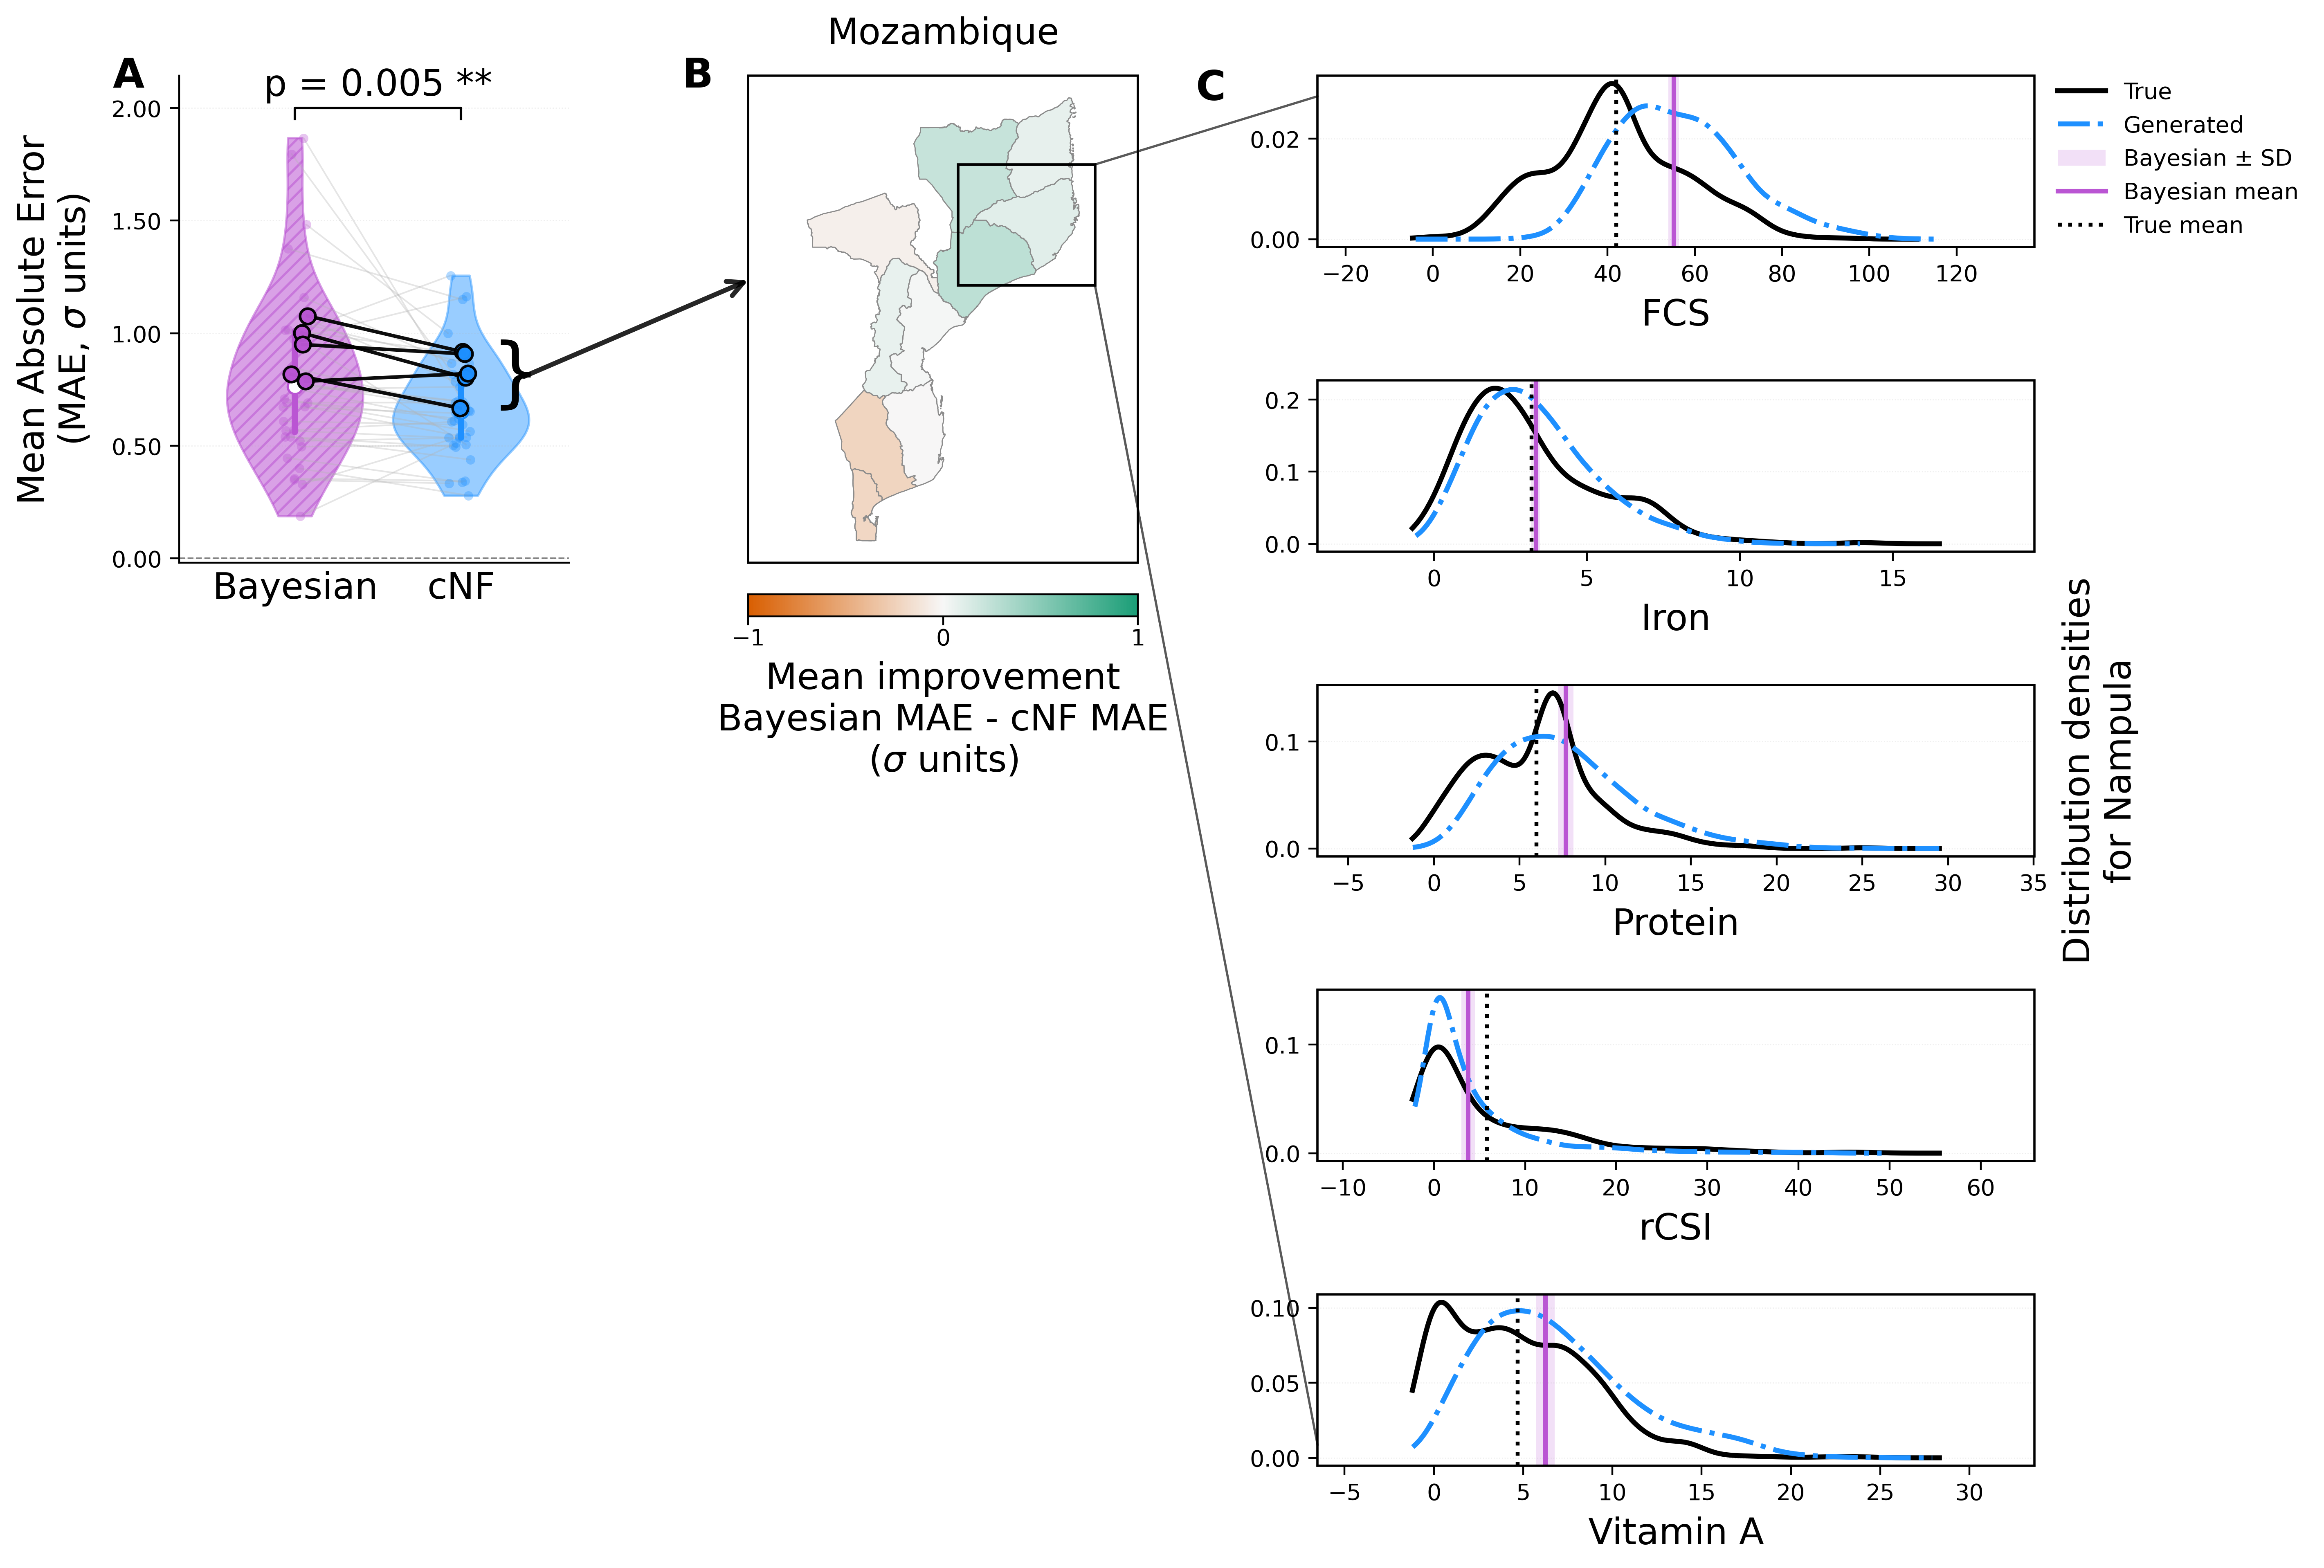

In [36]:
# =============================================================================
# Full plotting cell
#
# Figure:
#   A: paired violin plot, highlighting all Mozambique points
#   B: Mozambique ADM1 map, overall improvement averaged over variables
#   C: one selected ADM1, one distribution panel per variable
#
# Current fixes:
#   - Panel A and B top-aligned
#   - Panel letters placed cleanly
#   - Arrow points to the EXTERNAL zoom box around the selected ADM1
#   - Arrow thicker; brace smaller and slightly lower
#   - Colorbar directly below the map
#   - No individual titles on density plots
#   - Shared right-side y-label:
#       "Distribution densities for <region>"
#   - Legend outside the distribution plots
#   - Density plots include negative values if present
#   - If a variable is non-negative, x-axis still shows a little below zero
#   - Main text sizes harmonized
# =============================================================================

import os
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle, ConnectionPatch
from scipy import stats
from scipy.stats import gaussian_kde

# -----------------------------------------------------------------------------
# Settings
# -----------------------------------------------------------------------------

MOZ_EXPERIMENT = "moz_vam"
CHOSEN_ADM1_NORM = "nampula"   # try also: "niassa", "sofala", "cabodelgado"

OUT_PREFIX = f"mozambique_overall_map_variable_densities_{CHOSEN_ADM1_NORM}_final"

C_BAYES = "mediumorchid"
C_GEN = "dodgerblue"
C_MOZ = "black"

MAIN_TEXT_SIZE = 16
AXIS_TEXT_SIZE = 12
TICK_TEXT_SIZE = 10
LEGEND_TEXT_SIZE = 10
PANEL_LETTER_SIZE = 18

IMPROVEMENT_CMAP = LinearSegmentedColormap.from_list(
    "improvement_orange_white_green",
    ["#d95f02", "#f7f7f7", "#1b9e77"],
    N=256
)

DENSITY_PAD_FRAC = 0.18
DENSITY_MIN_WIDTH = 4.0
DENSITY_GRIDSIZE = 350
BELOW_ZERO_FRAC = 0.05

# -----------------------------------------------------------------------------
# Robust ADM1 normalization
# -----------------------------------------------------------------------------

ADM1_ALIASES = {
    "zambzia": "zambezia",
    "zambezia": "zambezia",

    "maputoprovnci": "maputoprovincia",
    "maputoprovinci": "maputoprovincia",
    "maputoprovincia": "maputoprovincia",
    "maputoprov": "maputoprovincia",

    "cabodelgado": "cabodelgado",
    "maputocidade": "maputocidade",
}

def _strip_accents(text):
    text = unicodedata.normalize("NFKD", str(text))
    return "".join(ch for ch in text if not unicodedata.combining(ch))

def _norm_name(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()
    x = _strip_accents(x)
    x = re.sub(r"[^a-z0-9]+", "", x)
    x = ADM1_ALIASES.get(x, x)

    return x

def _safe_improvement(bayes_err, gen_err):
    bayes_err = np.asarray(bayes_err, dtype=float)
    gen_err = np.asarray(gen_err, dtype=float)

    return np.where(
        np.isfinite(bayes_err) & np.isfinite(gen_err),
        bayes_err - gen_err,
        np.nan
    )

# -----------------------------------------------------------------------------
# Adaptive density helpers
# -----------------------------------------------------------------------------

def _adaptive_density_grid(seed_value_arrays, gridsize=DENSITY_GRIDSIZE):
    """
    Build a density grid that:
      - includes negative values if the variable has them
      - otherwise starts slightly below zero
      - includes enough right-side padding
    """
    clean_arrays = []

    for values in seed_value_arrays:
        values = pd.Series(values).dropna().astype(float).values
        values = values[np.isfinite(values)]
        if len(values) >= 2:
            clean_arrays.append(values)

    if len(clean_arrays) == 0:
        return None, None

    all_values = np.concatenate(clean_arrays)
    vmin = np.nanmin(all_values)
    vmax = np.nanmax(all_values)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return None, None

    if vmax <= vmin:
        center = vmin
        lo = center - 1.0
        hi = center + 1.0
    else:
        width = vmax - vmin

        if vmin >= 0:
            lo = -BELOW_ZERO_FRAC * max(width, 1.0)
        else:
            lo = vmin - DENSITY_PAD_FRAC * width

        hi = vmax + DENSITY_PAD_FRAC * width

    x = np.linspace(lo, hi, gridsize)

    densities = []

    for values in clean_arrays:
        try:
            kde = gaussian_kde(values)
            densities.append(kde(x))
        except Exception:
            pass

    if len(densities) == 0:
        return None, None

    y = np.mean(np.vstack(densities), axis=0)

    return x, y


def make_distribution_data_for_panel_c_adaptive(selected_point, selected_adm1_norm):
    experiment = str(selected_point["experiment"])
    variable = str(selected_point["variable"])

    adm1_candidates = [
        "adm1_norm",
        "adm1name",
        "adm1",
        "ADM1",
        "ADM1_EN",
        "admin1Name",
        "region"
    ]

    full_seed_arrays = []
    gen_seed_arrays = []

    used_full_paths = []
    used_gen_paths = []

    for seed_id in SEED_IDS:
        full_path, gen_path = _seed_paths(
            experiment,
            train_id=TRAIN_ID,
            seed_id=seed_id
        )

        if not (os.path.exists(full_path) and os.path.exists(gen_path)):
            continue

        full_header = _read_csv_header(full_path)
        gen_header = _read_csv_header(gen_path)

        if variable not in full_header or variable not in gen_header:
            continue

        full_adm1_col = next((c for c in adm1_candidates if c in full_header), None)
        gen_adm1_col = next((c for c in adm1_candidates if c in gen_header), None)

        if full_adm1_col is None or gen_adm1_col is None:
            continue

        full_df = pd.read_csv(full_path, usecols=[full_adm1_col, variable])
        gen_df = pd.read_csv(gen_path, usecols=[gen_adm1_col, variable])

        full_sub = _filter_adm1(full_df, selected_adm1_norm)
        gen_sub = _filter_adm1(gen_df, selected_adm1_norm)

        full_values = pd.to_numeric(full_sub[variable], errors="coerce").dropna().values
        gen_values = pd.to_numeric(gen_sub[variable], errors="coerce").dropna().values

        full_values = full_values[np.isfinite(full_values)]
        gen_values = gen_values[np.isfinite(gen_values)]

        if len(full_values) > 0:
            full_seed_arrays.append(full_values)
            used_full_paths.append(full_path)

        if len(gen_values) > 0:
            gen_seed_arrays.append(gen_values)
            used_gen_paths.append(gen_path)

    if len(full_seed_arrays) == 0:
        raise ValueError(f"No usable full-data arrays found for ADM1 {selected_adm1_norm}.")
    if len(gen_seed_arrays) == 0:
        raise ValueError(f"No usable generated arrays found for ADM1 {selected_adm1_norm}.")

    full_x, full_y = _adaptive_density_grid(full_seed_arrays)
    gen_x, gen_y = _adaptive_density_grid(gen_seed_arrays)

    return {
        "variable": variable,
        "full_paths": used_full_paths,
        "gen_paths": used_gen_paths,
        "full_seed_arrays": full_seed_arrays,
        "gen_seed_arrays": gen_seed_arrays,
        "full_density_x": full_x,
        "full_density_y": full_y,
        "gen_density_x": gen_x,
        "gen_density_y": gen_y,
        "n_full_seeds": len(full_seed_arrays),
        "n_gen_seeds": len(gen_seed_arrays),
        "n_full_total": sum(len(v) for v in full_seed_arrays),
        "n_gen_total": sum(len(v) for v in gen_seed_arrays),
        "full_pooled_values": np.concatenate(full_seed_arrays),
        "gen_pooled_values": np.concatenate(gen_seed_arrays),
    }


def prepare_panel_c_bundle_adaptive(selected_point, selected_adm1_row):
    selected_adm1_norm = selected_adm1_row["adm1_norm"]

    dist_data = make_distribution_data_for_panel_c_adaptive(
        selected_point,
        selected_adm1_norm
    )

    eval_sub = results_eval[
        (results_eval["experiment"].astype(str) == str(selected_point["experiment"])) &
        (results_eval["variable"].astype(str) == str(selected_point["variable"]))
    ].copy()

    if "adm1_norm" not in eval_sub.columns:
        eval_sub["adm1_norm"] = eval_sub["adm1"].map(_norm_name)
    else:
        eval_sub["adm1_norm"] = eval_sub["adm1_norm"].map(_norm_name)

    eval_sub = eval_sub[eval_sub["adm1_norm"] == selected_adm1_norm].copy()

    if eval_sub.empty:
        raise ValueError(f"Could not find ADM1 {selected_adm1_norm} in results_eval.")

    bayes_mu = eval_sub["bayes_mean"].mean()

    bayes_sd_col = _find_col(
        eval_sub,
        [
            "bayes_sd",
            "bayes_std",
            "bayes_stddev",
            "bayes_sigma",
            "posterior_sd",
            "post_sd"
        ],
        required=False,
        label="Bayesian standard deviation column"
    )

    bayes_sd = eval_sub[bayes_sd_col].mean() if bayes_sd_col is not None else np.nan
    true_mean = np.nanmean(dist_data["full_pooled_values"])

    return {
        "adm1_name": selected_adm1_row["adm1_geometry_name"],
        "adm1_norm": selected_adm1_norm,
        "improvement": selected_adm1_row["improvement"],
        "geometry": selected_adm1_row["geometry"],
        "dist_data": dist_data,
        "bayes_mu": bayes_mu,
        "bayes_sd": bayes_sd,
        "true_mean": true_mean,
        "variable": selected_point["variable"],
    }

# -----------------------------------------------------------------------------
# Density x-limits
# -----------------------------------------------------------------------------

def density_xlim_for_bundle(bundle):
    dist_data = bundle["dist_data"]

    support_arrays = []

    for key in [
        "full_pooled_values",
        "gen_pooled_values",
        "full_density_x",
        "gen_density_x",
    ]:
        values = dist_data.get(key, None)
        if values is not None:
            values = np.asarray(values, dtype=float)
            values = values[np.isfinite(values)]
            if len(values) > 0:
                support_arrays.append(values)

    bayes_mu = bundle.get("bayes_mu", np.nan)
    bayes_sd = bundle.get("bayes_sd", np.nan)
    true_mean = bundle.get("true_mean", np.nan)

    points = []

    if np.isfinite(true_mean):
        points.append(true_mean)

    if np.isfinite(bayes_mu):
        points.append(bayes_mu)
        if np.isfinite(bayes_sd):
            points.extend([bayes_mu - bayes_sd, bayes_mu + bayes_sd])

    if len(points) > 0:
        support_arrays.append(np.asarray(points, dtype=float))

    if len(support_arrays) == 0:
        lo, hi = -0.5, 1.0
    else:
        support = np.concatenate(support_arrays)
        support = support[np.isfinite(support)]

        if len(support) == 0:
            lo, hi = -0.5, 1.0
        else:
            data_min = np.nanmin(support)
            data_max = np.nanmax(support)

            width = data_max - data_min

            if not np.isfinite(width) or width <= 0:
                width = max(abs(data_max), 1.0)

            if data_min >= 0:
                lo = -BELOW_ZERO_FRAC * max(width, 1.0)
            else:
                lo = data_min - DENSITY_PAD_FRAC * width

            hi = data_max + DENSITY_PAD_FRAC * width

    width = hi - lo

    if not np.isfinite(width) or width <= 0:
        lo, hi = -0.5, 1.0
        width = hi - lo

    if width < DENSITY_MIN_WIDTH:
        center = 0.5 * (lo + hi)
        lo = center - DENSITY_MIN_WIDTH / 2
        hi = center + DENSITY_MIN_WIDTH / 2

        if lo > -0.05:
            shift = lo + 0.05
            lo -= shift
            hi -= shift

    return lo, hi

# -----------------------------------------------------------------------------
# Density plotting helper
# -----------------------------------------------------------------------------

def _plot_density_curve_clipped(ax, x, y, xlim, **kwargs):
    if x is None or y is None:
        return None

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = (
        np.isfinite(x) &
        np.isfinite(y) &
        (x >= xlim[0]) &
        (x <= xlim[1])
    )

    if mask.sum() >= 2:
        line, = ax.plot(x[mask], y[mask], **kwargs)
        return line

    return None


def plot_panel_c_readable(ax, bundle, show_legend=True):
    dist_data = bundle["dist_data"]

    bayes_mu = bundle["bayes_mu"]
    bayes_sd = bundle["bayes_sd"]
    true_mean = bundle["true_mean"]

    varname = str(bundle["variable"])
    xlabel = DISPLAY_LABELS.get(varname, varname)

    xlim = density_xlim_for_bundle(bundle)

    _plot_density_curve_clipped(
        ax,
        dist_data["full_density_x"],
        dist_data["full_density_y"],
        xlim=xlim,
        linewidth=2.2,
        linestyle="-",
        color="black",
        label="True"
    )

    _plot_density_curve_clipped(
        ax,
        dist_data["gen_density_x"],
        dist_data["gen_density_y"],
        xlim=xlim,
        linewidth=2.2,
        linestyle="-.",
        color=C_GEN,
        label="Generated"
    )

    if np.isfinite(bayes_mu) and np.isfinite(bayes_sd):
        ax.axvspan(
            bayes_mu - bayes_sd,
            bayes_mu + bayes_sd,
            color=C_BAYES,
            alpha=0.18,
            linewidth=0,
            label="Bayesian ± SD"
        )

    if np.isfinite(bayes_mu):
        ax.axvline(
            bayes_mu,
            color=C_BAYES,
            linewidth=2.0,
            linestyle="-",
            label="Bayesian mean"
        )

    if np.isfinite(true_mean):
        ax.axvline(
            true_mean,
            color="black",
            linewidth=1.7,
            linestyle=":",
            label="True mean"
        )

    ax.set_xlim(*xlim)
    ax.set_title("")
    ax.set_xlabel(xlabel, fontsize=MAIN_TEXT_SIZE, labelpad=5)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=TICK_TEXT_SIZE)
    ax.grid(axis="y", linewidth=0.45, alpha=0.22, linestyle=":")

    if show_legend:
        ax.legend(
            fontsize=LEGEND_TEXT_SIZE,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.02),
            handlelength=2.1,
            frameon=False,
            borderaxespad=0.0
        )

    frame = Rectangle(
        (0, 0),
        1,
        1,
        transform=ax.transAxes,
        fill=False,
        edgecolor="black",
        linewidth=1.0,
        linestyle="-",
        clip_on=False,
        zorder=15
    )
    ax.add_patch(frame)

# -----------------------------------------------------------------------------
# Panel A data
# -----------------------------------------------------------------------------

plot_base = results_eval.dropna(
    subset=["bayes_abs_err_std", "gen_abs_err_std"]
).copy()

agg_df = (
    plot_base
    .groupby(["experiment", "variable"], as_index=False)
    .agg(
        bayes_err_mean=("bayes_abs_err_std", "mean"),
        cnf_err_mean=("gen_abs_err_std", "mean")
    )
    .sort_values(["experiment", "variable"])
    .reset_index(drop=True)
)

bayes_vals = agg_df["bayes_err_mean"].values
gen_vals = agg_df["cnf_err_mean"].values
n = len(agg_df)

is_moz = agg_df["experiment"].astype(str).eq(str(MOZ_EXPERIMENT)).values

t_stat, p_val = stats.ttest_rel(bayes_vals, gen_vals)

if p_val < 0.001:
    sig_label = "p < 0.001 ***"
elif p_val < 0.01:
    sig_label = f"p = {p_val:.3f} **"
elif p_val < 0.05:
    sig_label = f"p = {p_val:.3f} *"
else:
    sig_label = f"p = {p_val:.3f} n.s."

# -----------------------------------------------------------------------------
# Panel B data
# -----------------------------------------------------------------------------

moz_eval = results_eval[
    results_eval["experiment"].astype(str).eq(str(MOZ_EXPERIMENT))
].dropna(
    subset=["bayes_abs_err_std", "gen_abs_err_std"]
).copy()

if moz_eval.empty:
    raise ValueError(f"No usable rows found for experiment: {MOZ_EXPERIMENT}")

if "adm1_norm" not in moz_eval.columns:
    if "adm1" not in moz_eval.columns:
        raise ValueError("results_eval must contain either 'adm1_norm' or 'adm1'.")
    moz_eval["adm1_norm"] = moz_eval["adm1"].map(_norm_name)
else:
    moz_eval["adm1_norm"] = moz_eval["adm1_norm"].map(_norm_name)

moz_eval["improvement"] = _safe_improvement(
    moz_eval["bayes_abs_err_std"],
    moz_eval["gen_abs_err_std"]
)

moz_adm1_overall = (
    moz_eval
    .dropna(subset=["improvement", "adm1_norm"])
    .groupby("adm1_norm", as_index=False)
    .agg(
        improvement=("improvement", "mean"),
        bayes_error=("bayes_abs_err_std", "mean"),
        cnf_error=("gen_abs_err_std", "mean"),
        n_variables=("variable", "nunique"),
        n_rows=("improvement", "size")
    )
)

moz_geo = load_adm1_geometries_for_experiment(MOZ_EXPERIMENT)
moz_geo["adm1_norm"] = moz_geo["adm1_norm"].map(_norm_name)

moz_map_gdf = moz_geo.merge(
    moz_adm1_overall,
    on="adm1_norm",
    how="left"
)

# -----------------------------------------------------------------------------
# Choose ADM1 for Panel C
# -----------------------------------------------------------------------------

chosen_norm = _norm_name(CHOSEN_ADM1_NORM)
chosen_matches = moz_map_gdf[moz_map_gdf["adm1_norm"].eq(chosen_norm)]

if chosen_matches.empty:
    available = sorted(moz_map_gdf["adm1_norm"].dropna().unique())
    raise ValueError(
        f"Could not find ADM1 '{CHOSEN_ADM1_NORM}'. "
        f"Available normalized ADM1 names are:\n{available}"
    )

chosen_adm1_row = chosen_matches.iloc[0].copy()
region_name = chosen_adm1_row["adm1_geometry_name"]

print("Chosen ADM1:")
print({
    "adm1_geometry_name": region_name,
    "adm1_norm": chosen_adm1_row["adm1_norm"],
    "overall_improvement": chosen_adm1_row["improvement"],
})

# -----------------------------------------------------------------------------
# Panel C bundles
# -----------------------------------------------------------------------------

moz_variables = (
    moz_eval["variable"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

moz_variables = sorted(
    moz_variables,
    key=lambda x: DISPLAY_LABELS.get(x, x).lower()
)

bundles = []

for variable in moz_variables:
    selected_point = pd.Series({
        "experiment": MOZ_EXPERIMENT,
        "variable": variable
    })

    try:
        bundle = prepare_panel_c_bundle_adaptive(selected_point, chosen_adm1_row)
        bundles.append(bundle)
    except Exception as e:
        print(f"Skipping variable '{variable}' because density data could not be prepared:")
        print("  ", e)

if len(bundles) == 0:
    raise ValueError("No variable-level density bundles could be prepared for Panel C.")

# -----------------------------------------------------------------------------
# Figure style
# -----------------------------------------------------------------------------

plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          11,
    "axes.labelsize":     AXIS_TEXT_SIZE,
    "axes.titlesize":     MAIN_TEXT_SIZE,
    "xtick.labelsize":    TICK_TEXT_SIZE,
    "ytick.labelsize":    TICK_TEXT_SIZE,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    LEGEND_TEXT_SIZE,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

fig = plt.figure(figsize=(12.6, 9.6))

outer = fig.add_gridspec(
    nrows=2,
    ncols=3,
    width_ratios=[1.55, 1.55, 2.85],
    height_ratios=[1.00, 0.62],
    left=0.055,
    right=0.955,
    bottom=0.070,
    top=0.955,
    wspace=0.36,
    hspace=0.02
)

axA = fig.add_subplot(outer[0, 0])
axB = fig.add_subplot(outer[0, 1])

gsC = outer[:, 2].subgridspec(len(bundles), 1, hspace=0.78)
axC_list = [fig.add_subplot(gsC[i, 0]) for i in range(len(bundles))]

axA.set_anchor("N")
axB.set_anchor("N")

# -----------------------------------------------------------------------------
# Panel A
# -----------------------------------------------------------------------------

rng = np.random.default_rng(42)

xs = [0.0, 1.0]
vals_list = [bayes_vals, gen_vals]
colors = [C_BAYES, C_GEN]
alphas = [0.55, 0.45]
hatches = ["////", None]
labels = ["Bayesian", "cNF"]

for x, vals, color, alpha, hatch in zip(xs, vals_list, colors, alphas, hatches):
    parts = axA.violinplot(
        vals,
        positions=[x],
        widths=0.82,
        showmedians=False,
        showextrema=False
    )

    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(alpha)
        pc.set_linewidth(1.0)
        if hatch:
            pc.set_hatch(hatch)

    q25, med, q75 = np.percentile(vals, [25, 50, 75])

    axA.plot(
        [x, x],
        [q25, q75],
        color=color,
        linewidth=2.8,
        solid_capstyle="round",
        zorder=5
    )

    axA.scatter(
        x,
        med,
        color="white",
        s=42,
        zorder=6,
        linewidths=1.0,
        edgecolors=color
    )

j1 = rng.uniform(-0.08, 0.08, size=n)
j2 = rng.uniform(-0.08, 0.08, size=n)

x1 = xs[0] + j1
x2 = xs[1] + j2

for i in np.where(~is_moz)[0]:
    axA.plot(
        [x1[i], x2[i]],
        [bayes_vals[i], gen_vals[i]],
        color="0.70",
        linewidth=0.7,
        alpha=0.34,
        zorder=2
    )

axA.scatter(
    x1[~is_moz],
    bayes_vals[~is_moz],
    color=C_BAYES,
    s=17,
    alpha=0.34,
    linewidths=0,
    zorder=3
)

axA.scatter(
    x2[~is_moz],
    gen_vals[~is_moz],
    color=C_GEN,
    s=17,
    alpha=0.34,
    linewidths=0,
    zorder=3
)

for i in np.where(is_moz)[0]:
    axA.plot(
        [x1[i], x2[i]],
        [bayes_vals[i], gen_vals[i]],
        color=C_MOZ,
        linewidth=1.55,
        alpha=0.95,
        zorder=8
    )

axA.scatter(
    x1[is_moz],
    bayes_vals[is_moz],
    s=46,
    facecolors=C_BAYES,
    edgecolors=C_MOZ,
    linewidths=1.15,
    alpha=0.98,
    zorder=9
)

axA.scatter(
    x2[is_moz],
    gen_vals[is_moz],
    s=46,
    facecolors=C_GEN,
    edgecolors=C_MOZ,
    linewidths=1.15,
    alpha=0.98,
    zorder=9
)

ymin_data = min(np.nanmin(bayes_vals), np.nanmin(gen_vals))
ymax_data = max(np.nanmax(bayes_vals), np.nanmax(gen_vals))
yr = ymax_data - ymin_data

y_bottom = min(-0.02, ymin_data - 0.08 * yr)
y_bracket = ymax_data + 0.050 * yr
bracket_h = 0.030 * yr
y_text = y_bracket + bracket_h + 0.012 * yr
y_top = ymax_data + 0.165 * yr

axA.set_ylim(y_bottom, y_top)

axA.plot(
    [0.0, 0.0, 1.0, 1.0],
    [y_bracket, y_bracket + bracket_h, y_bracket + bracket_h, y_bracket],
    color="black",
    linewidth=1.1,
    clip_on=False
)

axA.text(
    0.5,
    y_text,
    sig_label,
    ha="center",
    va="bottom",
    fontsize=MAIN_TEXT_SIZE
)

axA.axhline(
    0,
    color="black",
    linewidth=0.7,
    linestyle="--",
    alpha=0.5,
    zorder=1
)

moz_y_values = np.concatenate([bayes_vals[is_moz], gen_vals[is_moz]])
moz_y_mid = float(np.nanmean(moz_y_values))

brace_x = 1.33
brace_y = moz_y_mid - 0.04 * yr

axA.text(
    brace_x,
    brace_y,
    "}",
    fontsize=34,
    ha="center",
    va="center",
    color="black",
    zorder=20
)

axA.set_xticks(xs)
axA.set_xticklabels(labels)
axA.set_ylabel(
    r"Mean Absolute Error" + "\n" + r"(MAE, $\sigma$ units)",
    fontsize=MAIN_TEXT_SIZE,
    labelpad=8
)
axA.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
axA.yaxis.set_major_locator(ticker.MaxNLocator(5))
axA.grid(axis="y", linewidth=0.5, alpha=0.22, linestyle=":")
axA.set_xlim(-0.7, 1.65)
axA.tick_params(axis="x", length=0, labelsize=MAIN_TEXT_SIZE)
axA.tick_params(axis="y", labelsize=TICK_TEXT_SIZE)
axA.set_box_aspect(1.25)
axA.set_anchor("N")

# -----------------------------------------------------------------------------
# Panel B
# -----------------------------------------------------------------------------

vmin, vmax = -1.0, 1.0

moz_map_gdf.boundary.plot(
    ax=axB,
    linewidth=0.45,
    color="0.55"
)

moz_map_gdf.plot(
    column="improvement",
    ax=axB,
    cmap=IMPROVEMENT_CMAP,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.45,
    edgecolor="0.55",
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "0.6",
        "hatch": "///",
        "label": "Missing"
    }
)

chosen_geom = chosen_adm1_row.geometry
chosen_bounds = None

if chosen_geom is not None and not chosen_geom.is_empty:
    xmin, ymin, xmax, ymax = chosen_geom.bounds
    dx = xmax - xmin
    dy = ymax - ymin

    pad_x = 0.15 * dx if dx > 0 else 0.1
    pad_y = 0.15 * dy if dy > 0 else 0.1

    xmin -= pad_x
    xmax += pad_x
    ymin -= pad_y
    ymax += pad_y

    chosen_bounds = (xmin, ymin, xmax, ymax)

    adm_box = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        edgecolor="black",
        linewidth=1.2,
        linestyle="-",
        zorder=12
    )
    axB.add_patch(adm_box)

frame = Rectangle(
    (0, 0),
    1,
    1,
    transform=axB.transAxes,
    fill=False,
    edgecolor="black",
    linewidth=1.0,
    clip_on=False,
    zorder=15
)
axB.add_patch(frame)

axB.set_title("Mozambique", fontsize=MAIN_TEXT_SIZE, pad=14)
axB.set_axis_off()
axB.set_box_aspect(1.25)
axB.set_anchor("N")

# -----------------------------------------------------------------------------
# Force Panel B to align with Panel A at the top
# -----------------------------------------------------------------------------

fig.canvas.draw()

posA = axA.get_position()
posB = axB.get_position()

axB.set_position([
    posB.x0,
    posA.y1 - posB.height,
    posB.width,
    posB.height
])

posB = axB.get_position()

# -----------------------------------------------------------------------------
# Colorbar directly below the final map position
# -----------------------------------------------------------------------------

cbar_height = 0.014
cbar_pad = 0.020

cax = fig.add_axes([
    posB.x0,
    posB.y0 - cbar_pad - cbar_height,
    posB.width,
    cbar_height
])

sm = plt.cm.ScalarMappable(
    cmap=IMPROVEMENT_CMAP,
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm._A = []

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal",
    ticks=[-1, 0, 1]
)

cbar.set_label(
    "Mean improvement\n"
    "Bayesian MAE - cNF MAE\n"
    r"($\sigma$ units)",
    fontsize=MAIN_TEXT_SIZE,
    labelpad=5
)

cbar.ax.tick_params(labelsize=TICK_TEXT_SIZE, pad=1)

# -----------------------------------------------------------------------------
# Arrow from brace to EXTERNAL zoom box around selected ADM1
# -----------------------------------------------------------------------------

if chosen_bounds is not None:
    xmin, ymin, xmax, ymax = chosen_bounds

    arrow_to_external_box = ConnectionPatch(
    xyA=(brace_x + 0.05, brace_y),
    coordsA=axA.transData,

    # Target: left-middle edge of the full Panel B axes/frame
    xyB=(0.0, 0.58),
    coordsB=axB.transAxes,

    arrowstyle="->",
    mutation_scale=17,
    linewidth=2.1,
    color="black",
    alpha=0.85,
    clip_on=False,
    zorder=50
    )
    fig.add_artist(arrow_to_external_box)

# -----------------------------------------------------------------------------
# Panel C
# -----------------------------------------------------------------------------

for i, (axC, bundle) in enumerate(zip(axC_list, bundles)):
    plot_panel_c_readable(
        axC,
        bundle,
        show_legend=(i == 0)
    )

# Shared right-side y-label
c_top = axC_list[0].get_position()
c_bottom = axC_list[-1].get_position()

c_mid_y = 0.5 * (c_top.y1 + c_bottom.y0)
c_right_x = c_top.x1 + 0.032

fig.text(
    c_right_x,
    c_mid_y,
    f"Distribution densities\nfor {region_name}",
    rotation=90,
    va="center",
    ha="center",
    fontsize=MAIN_TEXT_SIZE
)

# -----------------------------------------------------------------------------
# Connect map box to Panel C
# -----------------------------------------------------------------------------

if chosen_bounds is not None and len(axC_list) > 0:
    xmin, ymin, xmax, ymax = chosen_bounds

    con_BC_top = ConnectionPatch(
        xyA=(xmax, ymax),
        coordsA=axB.transData,
        xyB=(0, 0.88),
        coordsB=axC_list[0].transAxes,
        arrowstyle="-",
        linewidth=1.0,
        color="black",
        alpha=0.65,
        clip_on=False,
        zorder=30
    )

    con_BC_bottom = ConnectionPatch(
        xyA=(xmax, ymin),
        coordsA=axB.transData,
        xyB=(0, 0.12),
        coordsB=axC_list[-1].transAxes,
        arrowstyle="-",
        linewidth=1.0,
        color="black",
        alpha=0.65,
        clip_on=False,
        zorder=30
    )

    fig.add_artist(con_BC_top)
    fig.add_artist(con_BC_bottom)

# -----------------------------------------------------------------------------
# Panel letters after final repositioning
# -----------------------------------------------------------------------------

axA.text(
    -0.17, 1.04, "A",
    transform=axA.transAxes,
    fontsize=PANEL_LETTER_SIZE,
    fontweight="bold",
    va="top",
    ha="left"
)

axB.text(
    -0.17, 1.04, "B",
    transform=axB.transAxes,
    fontsize=PANEL_LETTER_SIZE,
    fontweight="bold",
    va="top",
    ha="left"
)

axC_list[0].text(
    -0.17, 1.04, "C",
    transform=axC_list[0].transAxes,
    fontsize=PANEL_LETTER_SIZE,
    fontweight="bold",
    va="top",
    ha="left"
)

# -----------------------------------------------------------------------------
# Save and show
# -----------------------------------------------------------------------------

fig.savefig(f"{OUT_PREFIX}.png", bbox_inches="tight", dpi=400)
fig.savefig(f"{OUT_PREFIX}.pdf", bbox_inches="tight")
fig.savefig(f"{OUT_PREFIX}.svg", bbox_inches="tight")

plt.show()